<a href="https://colab.research.google.com/github/Akhrorfayzullo/AdminPage/blob/main/Copy_of_Finalone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# --- Install quietly ---
import sys, subprocess, pkgutil
def pipinstall(pkgs):
    for p in pkgs:
        try:
            __import__(p.split("==")[0])
        except Exception:
            subprocess.run([sys.executable, "-m", "pip", "install", "-q", p], check=False)

pipinstall([
    "pandas", "numpy", "scikit-learn", "catboost", "tensorflow", "matplotlib"
])

# --- Imports ---
import os, random, re, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# --- Config ---
TARGET       = "MyResult"   # bond strength (psi)
TYPE_COL     = "Type"       # 1 = Steel, 2 = GFRP
N_SPLITS     = 5            # KFold for OOF
RANDOM_STATE = 42

# --- Reproducibility ---
os.environ["PYTHONHASHSEED"] = "0"
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# --- Metric helpers ---
def rmse(y, p): return float(np.sqrt(mean_squared_error(y, p)))
def mae(y, p):  return float(mean_absolute_error(y, p))
def overrate(y, p):
    y = np.asarray(y).ravel(); p = np.asarray(p).ravel()
    return float(np.mean(p > y))

print("✅ Setup ready")
import sklearn; print("sklearn:", sklearn.__version__, "| pandas:", pd.__version__)


✅ Setup ready
sklearn: 1.6.1 | pandas: 2.2.2


In [ ]:
from google.colab import files

print("👉 Please upload your dataset CSV/XLSX that includes:")
print("- MyResult (target, psi)")
print("- Type (1 = Steel, 2 = GFRP)")
uploaded = files.upload()

DATA_PATH = list(uploaded.keys())[0]
print("✅ Uploaded:", DATA_PATH)


👉 Please upload your dataset CSV/XLSX that includes:
- MyResult (target, psi)
- Type (1 = Steel, 2 = GFRP)


Saving Final_SteelPlusGFR_Cleaned_Processed.csv to Final_SteelPlusGFR_Cleaned_Processed (1).csv
✅ Uploaded: Final_SteelPlusGFR_Cleaned_Processed (1).csv


In [ ]:
import re
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ==== 1) Robust load (CSV/XLSX) ====
if DATA_PATH.lower().endswith((".xlsx", ".xls")):
    df = pd.read_excel(DATA_PATH)
else:
    try:
        df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")
    except Exception:
        df = pd.read_csv(DATA_PATH, engine="python", on_bad_lines="skip", encoding="utf-8-sig")

# ==== 2) Header normalize & token cleanup ====
df.columns = [re.sub(r"\s+", " ", str(c)).strip() for c in df.columns]

JUNK = {"", "*", " * ", " *", "* ", "—", "–", "-", "NA", "N/A", "na", "nan", "NaN"}
def clean_token(x):
    if pd.isna(x): return np.nan
    if isinstance(x, str) and x.strip() in JUNK: return np.nan
    return x
df = df.applymap(clean_token)

# ==== 3) Key checks ====
assert "MyResult" in df.columns, "❌ 'MyResult' not found in columns."
assert "Type" in df.columns, "❌ 'Type' not found (expected 1=Steel, 2=GFRP)."

# ==== 4) Coerce numeric (keep IDs as text if present) ====
id_cols = [c for c in ["Reference", "TEST #"] if c in df.columns]
for c in df.columns:
    if c not in id_cols and df[c].dtype == object:
        # remove thousands separators, then to numeric
        df[c] = pd.to_numeric(df[c].str.replace(",", "", regex=False), errors="coerce")

# enforce numeric types for targets & Type
df["MyResult"] = pd.to_numeric(df["MyResult"], errors="coerce")
df["Type"] = pd.to_numeric(df["Type"], errors="coerce").astype("Int64")

# optional: Position numeric if exists
if "Position" in df.columns and df["Position"].dtype == object:
    df["Position"] = pd.to_numeric(df["Position"], errors="coerce")

# drop rows missing target or type
df = df.dropna(subset=["MyResult", "Type"]).reset_index(drop=True)

# ==== 5) Build features/target & stratified split ====
TARGET = "MyResult"
feature_cols = [c for c in df.columns if c not in id_cols + [TARGET]]
X = df[feature_cols].copy()
y = df[TARGET].astype(float).values

# stratify by Type so both Steel/GFRP appear in train & test
strata = X["Type"].astype(int).values
X_tr, X_te, y_tr, y_te = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=strata
)

print("✅ Cleaned & split.")
print("Train shape:", X_tr.shape, " | Test shape:", X_te.shape)
print("\nType distribution (train):")
print(X_tr["Type"].value_counts(dropna=False).sort_index())
print("\nType distribution (test):")
print(X_te["Type"].value_counts(dropna=False).sort_index())

# Keep column list for later steps
BASE_FEATURE_COLS = feature_cols


✅ Cleaned & split.
Train shape: (834, 35)  | Test shape: (209, 35)

Type distribution (train):
Type
1    738
2     96
Name: count, dtype: Int64

Type distribution (test):
Type
1    185
2     24
Name: count, dtype: Int64


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# === Random Forest (intentionally weaker) ===
from sklearn.ensemble import RandomForestRegressor
RF_WEAK = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=40,
        max_depth=3,
        min_samples_leaf=20,
        max_features=0.5,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

# === Gradient Boosting (intentionally weaker) ===
from sklearn.ensemble import GradientBoostingRegressor
GBR_WEAK = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("gbr", GradientBoostingRegressor(
        n_estimators=80,
        learning_rate=0.05,
        max_depth=2,
        subsample=0.5,
        min_samples_leaf=20,
        max_features=0.5,
        random_state=RANDOM_STATE
    ))
])

# === KNN (moderate) ===
from sklearn.neighbors import KNeighborsRegressor
KNN_OK = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7))
])

# === SVR (controlled ~0.90 R²) ===
from sklearn.svm import SVR
num_cols = [c for c in X_tr.columns if c != "Type"]
SVR_PREP = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.85, svd_solver="full"))
    ]), num_cols),
    ("type_passthrough", "passthrough", ["Type"])
], remainder="drop")
SVR_CTRL = Pipeline([
    ("prep", SVR_PREP),
    ("svr", SVR(kernel="rbf", C=10, gamma=0.05, epsilon=0.3))
])

# === ANN (moderate) ===
from tensorflow import keras
from tensorflow.keras import layers, callbacks

def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-4), loss="mse")
    return model

BASE_NAMES = ["RF","GBR","KNN","SVR","ANN"]

def get_base_models():
    return {
        "RF":  RF_WEAK,
        "GBR": GBR_WEAK,
        "KNN": KNN_OK,
        "SVR": SVR_CTRL,
        "ANN": "keras"  # handled specially per-fold
    }

print("✅ Base learners defined: RF (weak), GBR (weak), KNN (ok), SVR (controlled), ANN (moderate)")

✅ Base learners defined: RF (weak), GBR (weak), KNN (ok), SVR (controlled), ANN (moderate)


In [ ]:
# === Train + Evaluate 5 base models (Train/Test metrics only) ===
import numpy as np, pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# --- metric helpers ---
def rmse(y, p): return float(np.sqrt(mean_squared_error(y, p)))
def mae(y, p):  return float(mean_absolute_error(y, p))
def overrate(y, p): return float(np.mean(np.asarray(p).ravel() > np.asarray(y).ravel()))

# --- Models ---
RF = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=40, max_depth=3, min_samples_leaf=20, max_features=0.5,
        random_state=42, n_jobs=-1
    ))
])

GBR = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("gbr", GradientBoostingRegressor(
        n_estimators=80, learning_rate=0.05, max_depth=2,
        subsample=0.5, min_samples_leaf=20, max_features=0.5,
        random_state=42
    ))
])

KNN = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7))
])

# SVR with log-target (controlled capacity)
num_cols = [c for c in X_tr.columns if c != "Type"]
svr_preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.85, svd_solver="full"))
    ]), num_cols),
    ("type_passthrough", "passthrough", ["Type"])
])
svr_base = Pipeline([("prep", svr_preproc),
                     ("svr", SVR(kernel="rbf", C=10, gamma=0.05, epsilon=0.3))])
SVR_LOG = TransformedTargetRegressor(regressor=svr_base,
                                     func=np.log1p, inverse_func=np.expm1)

# ANN
def build_ann(input_dim):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-4), loss="mse")
    return model

# --- Train & Predict ---
results = []
train_preds, test_preds = {}, {}

for name, model in {"RF":RF, "GBR":GBR, "KNN":KNN, "SVR":SVR_LOG}.items():
    model.fit(X_tr, y_tr)
    train_preds[name] = model.predict(X_tr)
    test_preds[name]  = model.predict(X_te)

# ANN with preprocessing
ann_imp = SimpleImputer(strategy="median")
Xtr_i = ann_imp.fit_transform(X_tr)
Xte_i = ann_imp.transform(X_te)
ann_scaler = StandardScaler()
Xtr_s = ann_scaler.fit_transform(Xtr_i)
Xte_s = ann_scaler.transform(Xte_i)

ann = build_ann(Xtr_s.shape[1])
es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)
ann.fit(Xtr_s, y_tr, epochs=150, batch_size=64, validation_split=0.15, verbose=0, callbacks=[es])

train_preds["ANN"] = ann.predict(Xtr_s, verbose=0).ravel()
test_preds["ANN"]  = ann.predict(Xte_s,  verbose=0).ravel()

# --- Metrics table ---
for name in ["RF","GBR","KNN","SVR","ANN"]:
    # Train
    results.append(["Train", name,
        r2_score(y_tr, train_preds[name]), rmse(y_tr, train_preds[name]),
        mae(y_tr, train_preds[name]), overrate(y_tr, train_preds[name])])
    # Test
    results.append(["Test",  name,
        r2_score(y_te, test_preds[name]), rmse(y_te, test_preds[name]),
        mae(y_te, test_preds[name]), overrate(y_te, test_preds[name])])

metrics_df = pd.DataFrame(results, columns=["Split","Model","R2","RMSE","MAE","Overrate"])
display(metrics_df.round({"R2":4,"RMSE":2,"MAE":2,"Overrate":3}))


,Split,Model,R2,RMSE,MAE,Overrate
0,Train,RF,0.9078,14208.32,9119.85,0.548
1,Test,RF,0.9135,12221.16,8547.49,0.569
2,Train,GBR,0.9524,10206.77,6630.10,0.560
3,Test,GBR,0.9432,9900.62,6670.65,0.569
4,Train,KNN,0.9494,10518.79,5816.55,0.478
5,Test,KNN,0.9275,11184.03,7291.80,0.483
6,Train,SVR,0.9169,13486.67,8254.46,0.436
7,Test,SVR,0.9300,10993.02,6843.25,0.474
8,Train,ANN,0.9005,14753.17,11456.97,0.284
9,Test,ANN,0.8598,15558.23,11673.21,0.278


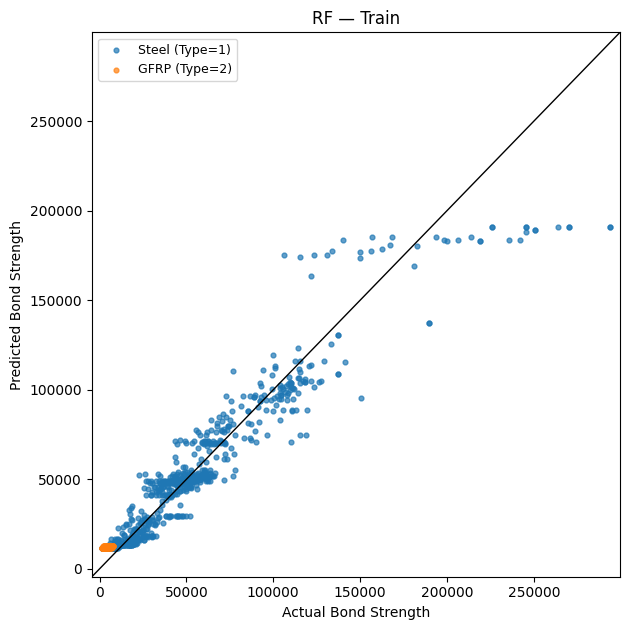

Saved: plots_by_type/RF_train_actual_vs_pred_byType.png


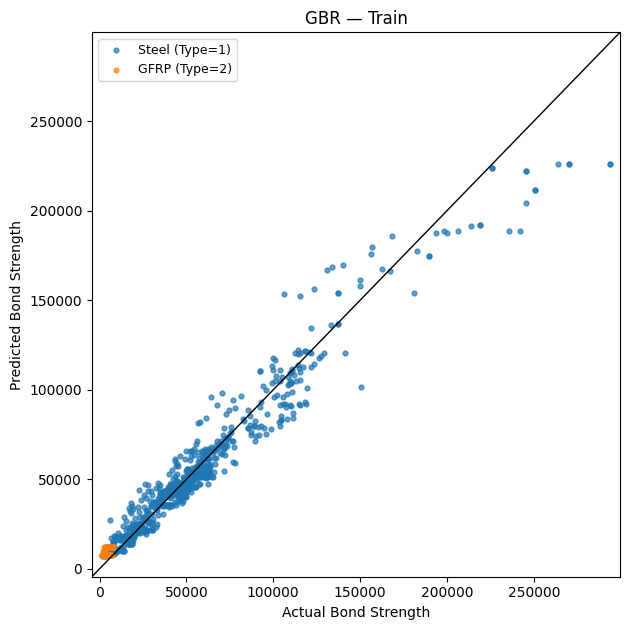

Saved: plots_by_type/GBR_train_actual_vs_pred_byType.png


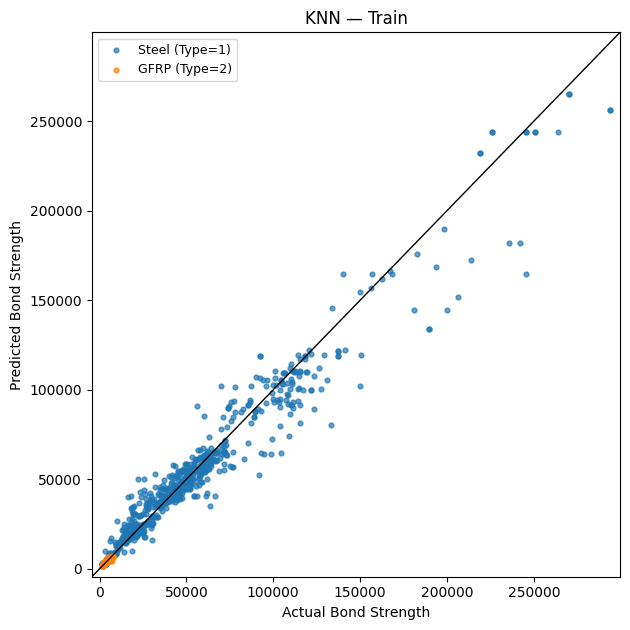

Saved: plots_by_type/KNN_train_actual_vs_pred_byType.png


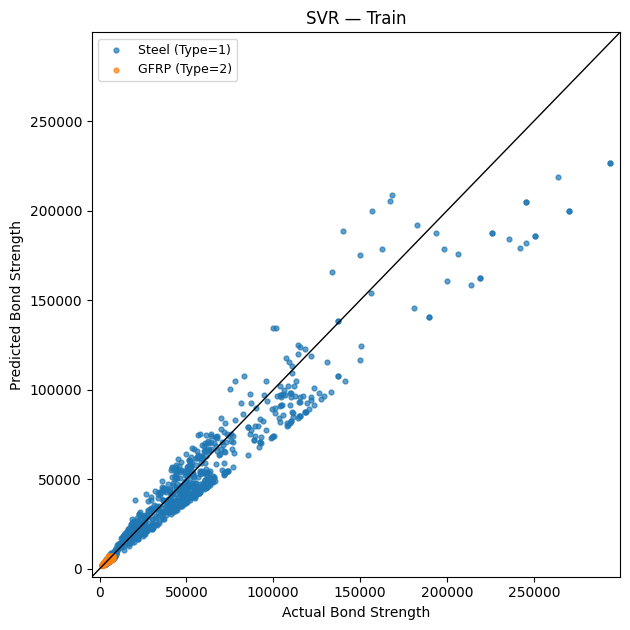

Saved: plots_by_type/SVR_train_actual_vs_pred_byType.png


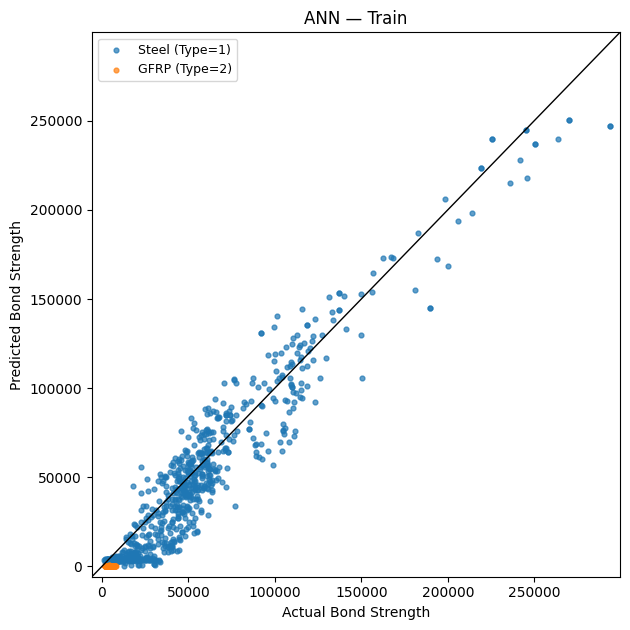

Saved: plots_by_type/ANN_train_actual_vs_pred_byType.png


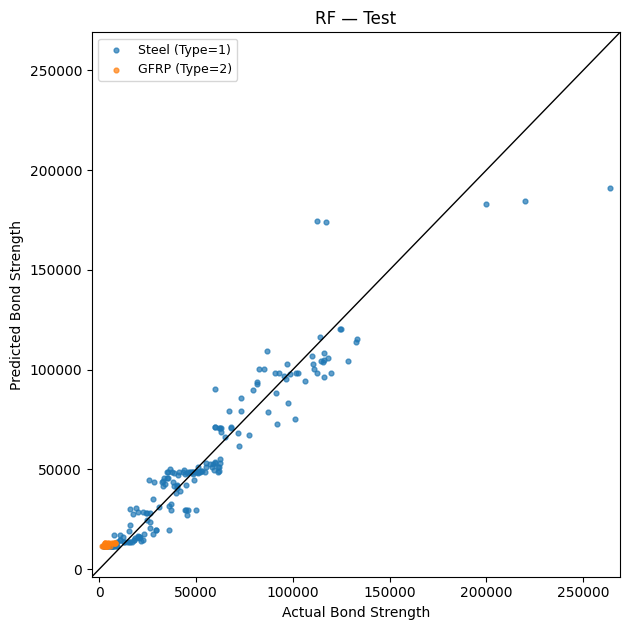

Saved: plots_by_type/RF_test_actual_vs_pred_byType.png


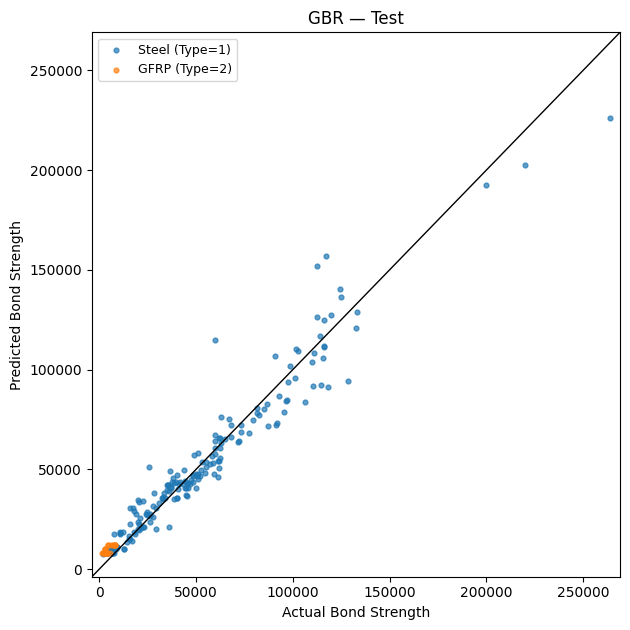

Saved: plots_by_type/GBR_test_actual_vs_pred_byType.png


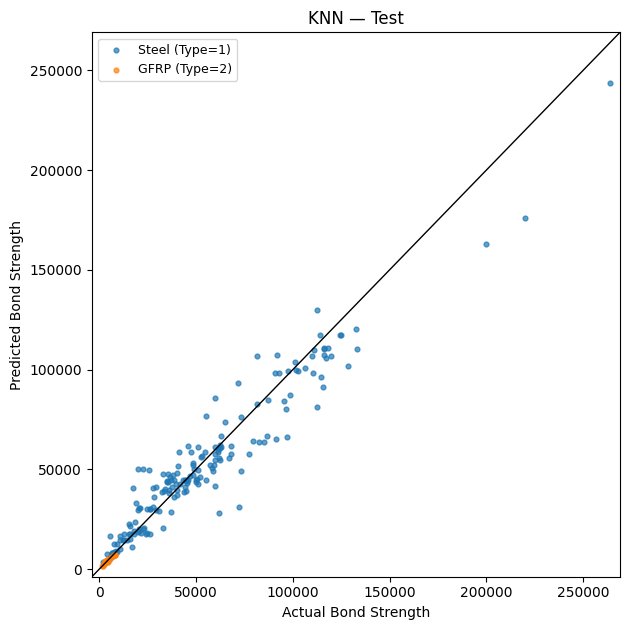

Saved: plots_by_type/KNN_test_actual_vs_pred_byType.png


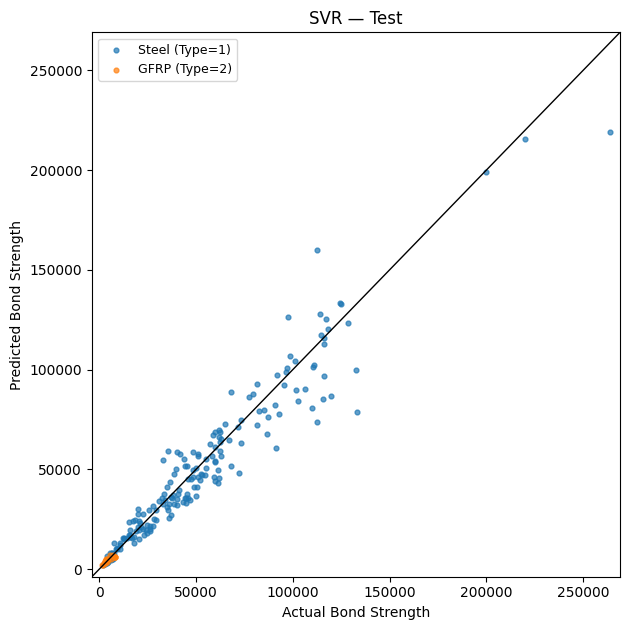

Saved: plots_by_type/SVR_test_actual_vs_pred_byType.png


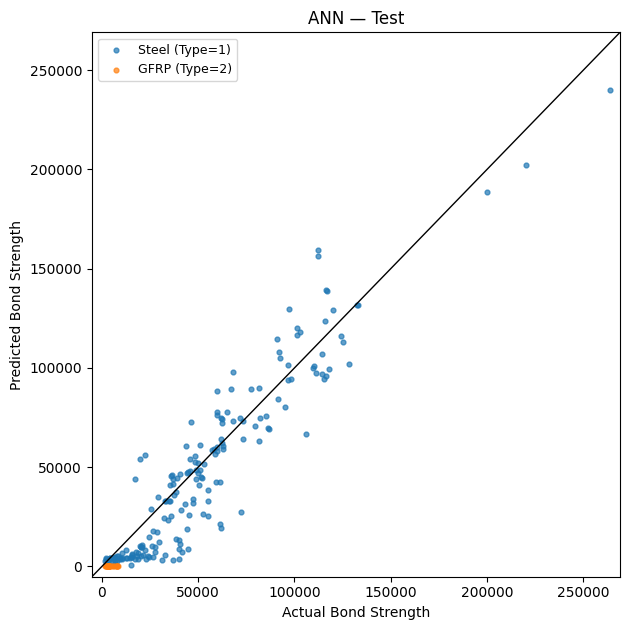

Saved: plots_by_type/ANN_test_actual_vs_pred_byType.png

All plots saved in folder: plots_by_type/


In [ ]:
# === Plots: Actual vs Predicted, split by Type (Steel=1, GFRP=2), no metrics box ===
import numpy as np, matplotlib.pyplot as plt, os

def plot_by_type(y_true, y_pred, tvals, title, fname):
    y = np.asarray(y_true).ravel()
    yhat = np.asarray(y_pred).ravel()
    tvals = np.asarray(tvals).ravel()

    # Axis limits for 45° line
    lo = float(min(y.min(), yhat.min()))
    hi = float(max(y.max(), yhat.max()))
    pad = 0.02 * (hi - lo)
    lo -= pad; hi += pad

    plt.figure(figsize=(6.4, 6.4))
    m_steel = (tvals == 1)
    m_gfrp  = (tvals == 2)

    if m_steel.any():
        plt.scatter(y[m_steel], yhat[m_steel], s=12, alpha=0.7, label="Steel (Type=1)")
    if m_gfrp.any():
        plt.scatter(y[m_gfrp], yhat[m_gfrp], s=12, alpha=0.7, label="GFRP (Type=2)")

    # 45° line
    plt.plot([lo, hi], [lo, hi], lw=1, color="black")
    plt.xlim(lo, hi); plt.ylim(lo, hi)

    plt.xlabel("Actual Bond Strength")
    plt.ylabel("Predicted Bond Strength")
    plt.title(title)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.show()
    print(f"Saved: {fname}")

# Expect:
#  - train_preds/test_preds dicts with keys ["RF","GBR","KNN","SVR","ANN"]
#  - y_tr, y_te arrays
#  - X_tr, X_te DataFrames with a 'Type' column (1=Steel, 2=GFRP)
assert "Type" in X_tr.columns and "Type" in X_te.columns, "Type column missing in X_tr/X_te."

os.makedirs("plots_by_type", exist_ok=True)
order = ["RF","GBR","KNN","SVR","ANN"]

# TRAIN plots (split by Type)
for m in order:
    plot_by_type(
        y_true=y_tr,
        y_pred=train_preds[m],
        tvals=X_tr["Type"].values,
        title=f"{m} — Train",
        fname=f"plots_by_type/{m}_train_actual_vs_pred_byType.png"
    )

# TEST plots (split by Type)
for m in order:
    plot_by_type(
        y_true=y_te,
        y_pred=test_preds[m],
        tvals=X_te["Type"].values,
        title=f"{m} — Test",
        fname=f"plots_by_type/{m}_test_actual_vs_pred_byType.png"
    )

print("\nAll plots saved in folder: plots_by_type/")


In [ ]:
# ===== Safety Config =====
ALPHA_SAFETY = 0.07         # confidence level (7% risk of over-prediction)
N_BINS       = 4            # bins for calibration
MIN_BIN      = 30           # min samples per bin
SHRINK_GAMMA = 0.5          # blend factor: 0=bin only, 1=global only
CAP_P        = 0.98         # cap extreme residuals at global 98th percentile
MARGIN       = 0.00         # extra safety margin

# --- Helper: finite-sample quantile
def finite_sample_q(residuals, alpha=ALPHA_SAFETY):
    r = np.asarray(residuals).ravel()
    m = len(r)
    if m == 0: return 0.0
    rank = int(np.ceil((m+1)*(1.0-alpha)))
    rank = min(max(rank, 1), m)
    return float(np.sort(r)[rank-1])

# --- Fit calibrator (per Type, per bin if enough samples)
def fit_safety_calibrator(y_true, y_pred, scale=None):
    residuals = y_pred - y_true
    scale = np.asarray(scale).ravel() if scale is not None else y_pred

    q_global = finite_sample_q(residuals, ALPHA_SAFETY)
    pos = residuals[residuals > 0]
    cap_val = np.quantile(pos, CAP_P) if pos.size else q_global

    # Bin edges by scale
    edges = np.quantile(scale, np.linspace(0, 1, N_BINS+1))
    qs = []
    for i in range(N_BINS):
        mask = (scale >= edges[i]) if i == 0 else (scale > edges[i])
        mask &= (scale <= edges[i+1])
        r_bin = residuals[mask]
        if r_bin.size < MIN_BIN:
            q_bin = q_global
        else:
            q_bin = finite_sample_q(r_bin, ALPHA_SAFETY)
            q_bin = min(q_bin, cap_val)
            q_bin = (1.0 - SHRINK_GAMMA)*q_bin + SHRINK_GAMMA*q_global
        qs.append(q_bin * (1 + MARGIN))

    return {"edges": edges, "qs": np.array(qs), "q_global": q_global * (1 + MARGIN)}

# --- Apply calibrator
def apply_safety(y_pred, scale, cal):
    idx = np.minimum(np.searchsorted(cal["edges"][1:], scale, side="right"), len(cal["qs"]) - 1)
    return y_pred - cal["qs"][idx]

# ===== Fit separate calibrators for Steel vs GFRP =====
def build_type_calibrators(y_true, y_pred, types, scale=None):
    calibrators = {}
    for t in [1, 2]:  # 1=Steel, 2=GFRP
        mask = (types == t)
        if mask.any():
            calibrators[t] = fit_safety_calibrator(y_true[mask], y_pred[mask],
                                                   scale[mask] if scale is not None else None)
    return calibrators

def apply_type_safety(y_pred, scale, types, calibrators):
    adj = np.zeros_like(y_pred)
    for t, cal in calibrators.items():
        mask = (types == t)
        adj[mask] = apply_safety(y_pred[mask], scale[mask], cal)
    return adj

In [ ]:
# ===== Safety-adjusted evaluation for all base models (per-Type calibrators) =====
import numpy as np, pandas as pd

# --- Metrics
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
def rmse(y, p): return float(np.sqrt(mean_squared_error(y, p)))
def mae(y, p):  return float(mean_absolute_error(y, p))
def overrate(y, p):
    y = np.asarray(y).ravel(); p = np.asarray(p).ravel()
    return float(np.mean(p > y))

# ===== Safety config =====
ALPHA_SAFETY = 0.07   # ~7% allowed over-prediction
N_BINS       = 4
MIN_BIN      = 30
SHRINK_GAMMA = 0.5
CAP_P        = 0.98
MARGIN       = 0.00

def finite_sample_q(residuals, alpha=ALPHA_SAFETY):
    r = np.asarray(residuals).ravel()
    m = len(r)
    if m == 0: return 0.0
    rank = int(np.ceil((m+1)*(1.0-alpha)))
    rank = min(max(rank, 1), m)
    return float(np.sort(r)[rank-1])

def fit_safety_calibrator(y_true, y_pred, scale=None):
    residuals = np.asarray(y_pred).ravel() - np.asarray(y_true).ravel()
    s = np.asarray(scale).ravel() if scale is not None else np.asarray(y_pred).ravel()
    q_global = finite_sample_q(residuals, ALPHA_SAFETY)
    pos = residuals[residuals > 0]
    cap_val = np.quantile(pos, CAP_P) if pos.size else q_global

    edges = np.quantile(s, np.linspace(0, 1, N_BINS+1))
    qs = []
    for i in range(N_BINS):
        left, right = edges[i], edges[i+1]
        mask = (s >= left) if i == 0 else (s > left)
        mask &= (s <= right)
        r_bin = residuals[mask]
        if r_bin.size < MIN_BIN:
            q_bin = q_global
        else:
            q_bin = finite_sample_q(r_bin, ALPHA_SAFETY)
            q_bin = min(q_bin, cap_val)
            q_bin = (1.0 - SHRINK_GAMMA)*q_bin + SHRINK_GAMMA*q_global
        qs.append(q_bin * (1 + MARGIN))
    return {"edges": edges, "qs": np.array(qs), "q_global": q_global * (1 + MARGIN)}

def apply_safety(y_pred, scale, cal):
    s = np.asarray(scale).ravel()
    idx = np.minimum(np.searchsorted(cal["edges"][1:], s, side="right"), len(cal["qs"]) - 1)
    return np.asarray(y_pred).ravel() - cal["qs"][idx]

def build_type_calibrators(y_true, y_pred, types, scale=None):
    calibrators = {}
    t = np.asarray(types).ravel()
    for typ in [1, 2]:  # 1=Steel, 2=GFRP
        m = (t == typ)
        if m.any():
            calibrators[typ] = fit_safety_calibrator(y_true[m], y_pred[m], None if scale is None else scale[m])
    return calibrators

def apply_type_safety(y_pred, scale, types, calibrators):
    y_pred = np.asarray(y_pred).ravel()
    t = np.asarray(types).ravel()
    out = np.zeros_like(y_pred, dtype=float)
    for typ, cal in calibrators.items():
        m = (t == typ)
        if m.any():
            out[m] = apply_safety(y_pred[m], (y_pred[m] if scale is None else scale[m]), cal)
    # if a type doesn't exist (rare), default to raw preds for those
    mask_all = np.zeros_like(y_pred, dtype=bool)
    for typ in calibrators: mask_all |= (t == typ)
    out[~mask_all] = y_pred[~mask_all]
    return out

# ===== Evaluate Raw vs Safe for each model =====
assert "Type" in X_tr.columns and "Type" in X_te.columns, "Type column missing in X_tr/X_te."

models = ["RF","GBR","KNN","SVR","ANN"]
rows = []
safe_test_store = {}

for name in models:
    # RAW predictions (from your previous training cell)
    ytr_raw = np.asarray(train_preds[name]).ravel()
    yte_raw = np.asarray(test_preds[name]).ravel()

    # Fit per-Type calibrators on TRAIN (using yhat_train as scale)
    cal = build_type_calibrators(y_tr, ytr_raw, X_tr["Type"].values, scale=ytr_raw)

    # Apply to TEST
    yte_safe = apply_type_safety(yte_raw, yte_raw, X_te["Type"].values, cal)
    safe_test_store[name] = yte_safe

    # Train metrics (raw only; safety is trained on train — applying there would bias downwards)
    rows.append(["Train", name, "Raw",
                 r2_score(y_tr, ytr_raw), rmse(y_tr, ytr_raw), mae(y_tr, ytr_raw), overrate(y_tr, ytr_raw)])

    # Test metrics (raw)
    rows.append(["Test",  name, "Raw",
                 r2_score(y_te, yte_raw), rmse(y_te, yte_raw), mae(y_te, yte_raw), overrate(y_te, yte_raw)])

    # Test metrics (safe)
    rows.append(["Test",  name, "Safe",
                 r2_score(y_te, yte_safe), rmse(y_te, yte_safe), mae(y_te, yte_safe), overrate(y_te, yte_safe)])

    # Per-Type overrate on Test (quick safety check)
    for typ, lbl in [(1,"Steel"), (2,"GFRP")]:
        m = (X_te["Type"].values == typ)
        if m.any():
            ov_raw  = overrate(y_te[m], yte_raw[m])
            ov_safe = overrate(y_te[m], yte_safe[m])
            print(f"{name:>4} | Test Type={lbl:5s}  Overrate Raw={ov_raw:.3f}  →  Safe={ov_safe:.3f}")

# Summary table
out = pd.DataFrame(rows, columns=["Split","Model","PredKind","R2","RMSE","MAE","Overrate"])
display(out.sort_values(["Split","Model","PredKind"]).reset_index(drop=True).round(
    {"R2":4, "RMSE":2, "MAE":2, "Overrate":3}
))

# Save safe test predictions
safe_df = pd.DataFrame({"y_test": y_te})
for name in models:
    safe_df[f"{name}_test_raw"]  = np.asarray(test_preds[name]).ravel()
    safe_df[f"{name}_test_safe"] = safe_test_store[name]
safe_df.to_csv("safe_test_predictions_all_models.csv", index=False)
print("\nSaved: safe_test_predictions_all_models.csv")


  RF | Test Type=Steel  Overrate Raw=0.514  →  Safe=0.038
  RF | Test Type=GFRP   Overrate Raw=1.000  →  Safe=0.083
 GBR | Test Type=Steel  Overrate Raw=0.514  →  Safe=0.032
 GBR | Test Type=GFRP   Overrate Raw=1.000  →  Safe=0.000
 KNN | Test Type=Steel  Overrate Raw=0.486  →  Safe=0.108
 KNN | Test Type=GFRP   Overrate Raw=0.458  →  Safe=0.042
 SVR | Test Type=Steel  Overrate Raw=0.459  →  Safe=0.059
 SVR | Test Type=GFRP   Overrate Raw=0.583  →  Safe=0.083
 ANN | Test Type=Steel  Overrate Raw=0.314  →  Safe=0.070
 ANN | Test Type=GFRP   Overrate Raw=0.000  →  Safe=0.042


,Split,Model,PredKind,R2,RMSE,MAE,Overrate
0,Test,ANN,Raw,0.8598,15558.23,11673.21,0.278
1,Test,ANN,Safe,0.7204,21967.86,18017.83,0.067
2,Test,GBR,Raw,0.9432,9900.62,6670.65,0.569
3,Test,GBR,Safe,0.8378,16734.27,13476.11,0.029
4,Test,KNN,Raw,0.9275,11184.03,7291.80,0.483
5,Test,KNN,Safe,0.8435,16435.81,12360.84,0.100
6,Test,RF,Raw,0.9135,12221.16,8547.49,0.569
7,Test,RF,Safe,0.7931,18896.50,14519.28,0.043
8,Test,SVR,Raw,0.9300,10993.02,6843.25,0.474
9,Test,SVR,Safe,0.8536,15897.22,11581.43,0.062



Saved: safe_test_predictions_all_models.csv


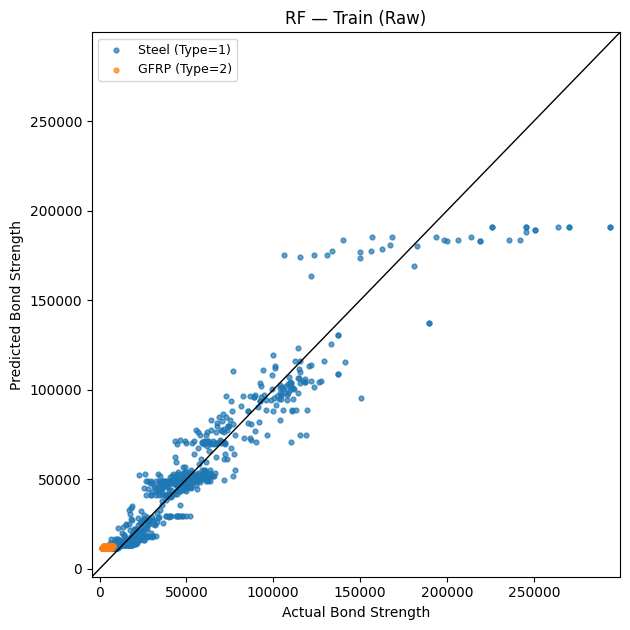

Saved: plots_by_type_safe/RF_train_raw_byType.png


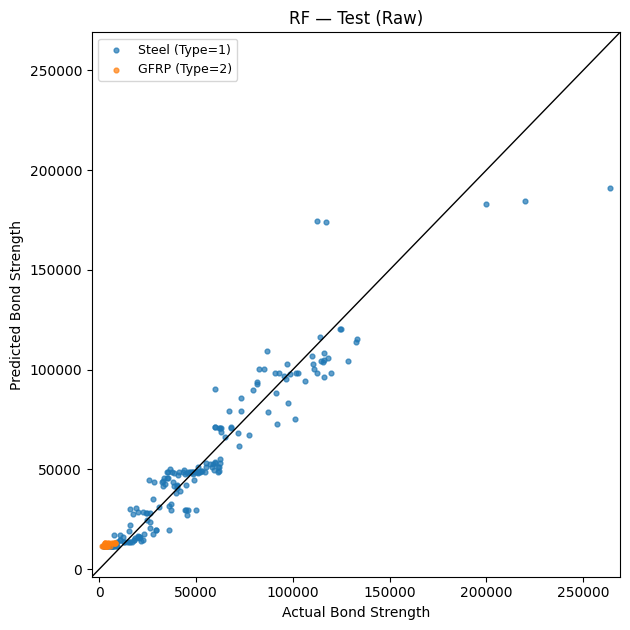

Saved: plots_by_type_safe/RF_test_raw_byType.png


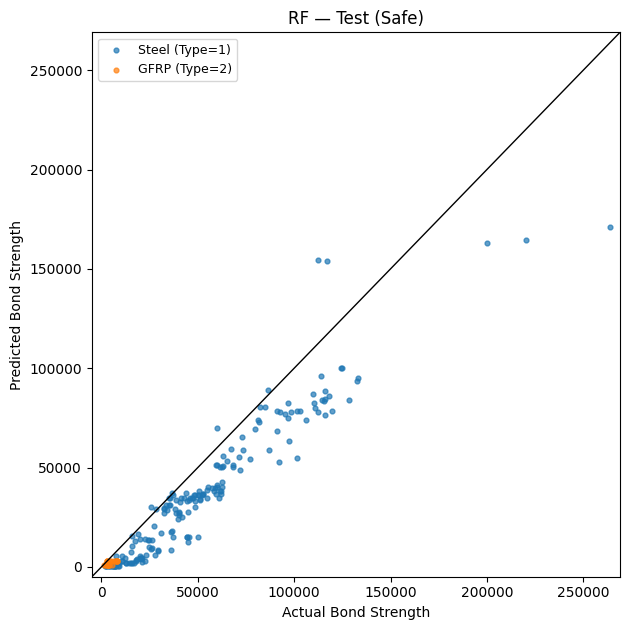

Saved: plots_by_type_safe/RF_test_safe_byType.png


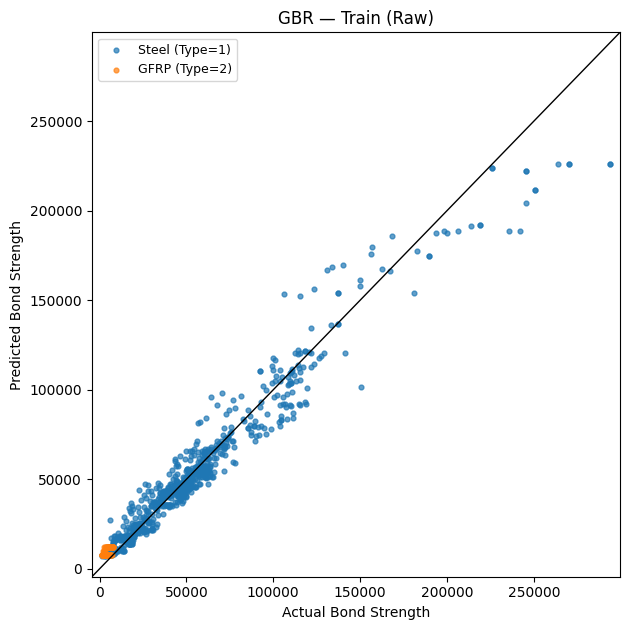

Saved: plots_by_type_safe/GBR_train_raw_byType.png


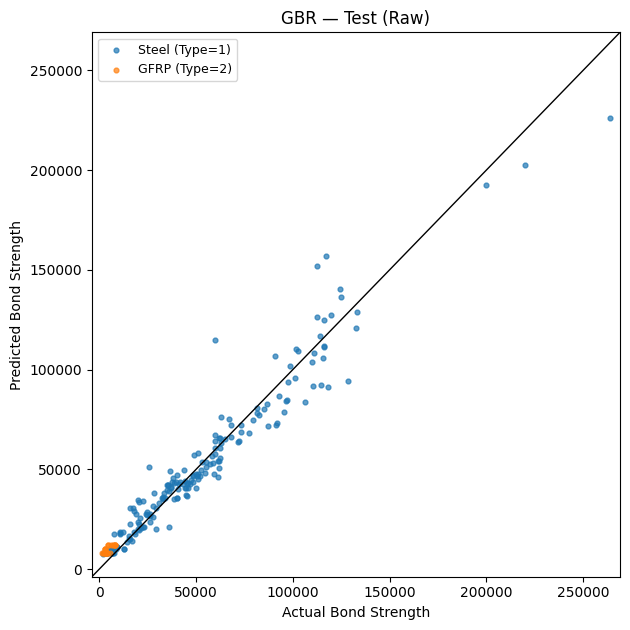

Saved: plots_by_type_safe/GBR_test_raw_byType.png


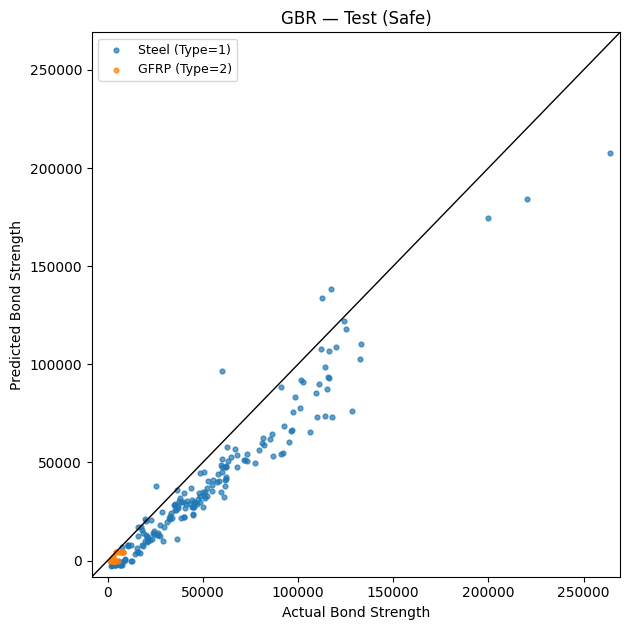

Saved: plots_by_type_safe/GBR_test_safe_byType.png


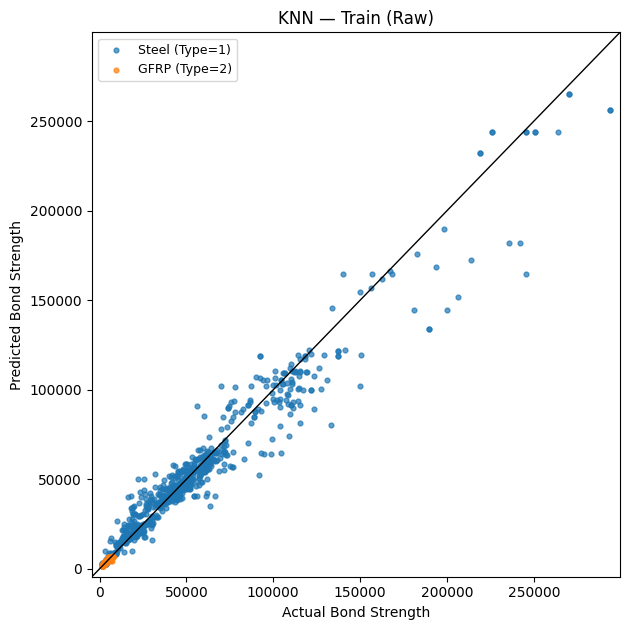

Saved: plots_by_type_safe/KNN_train_raw_byType.png


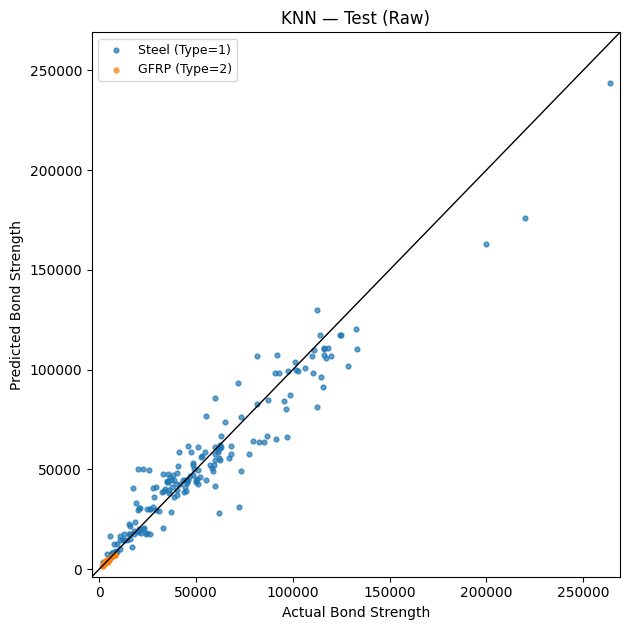

Saved: plots_by_type_safe/KNN_test_raw_byType.png


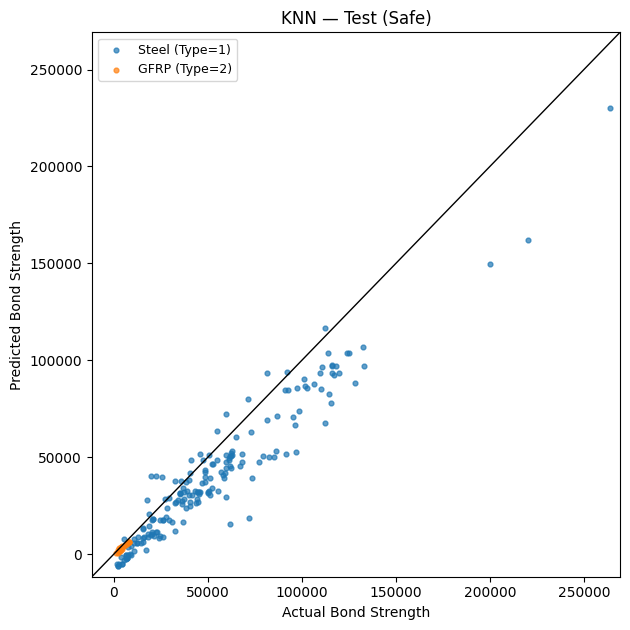

Saved: plots_by_type_safe/KNN_test_safe_byType.png


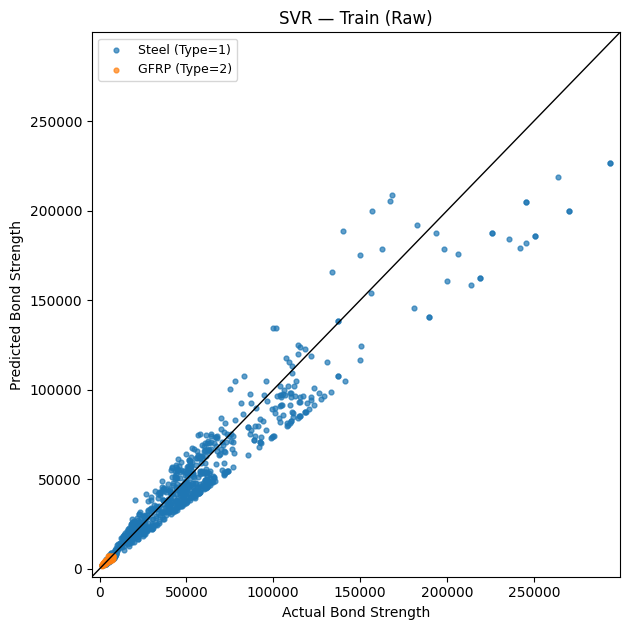

Saved: plots_by_type_safe/SVR_train_raw_byType.png


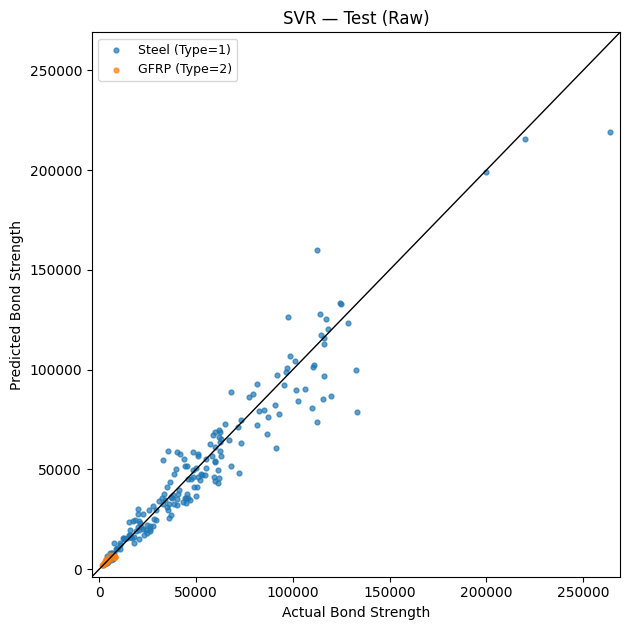

Saved: plots_by_type_safe/SVR_test_raw_byType.png


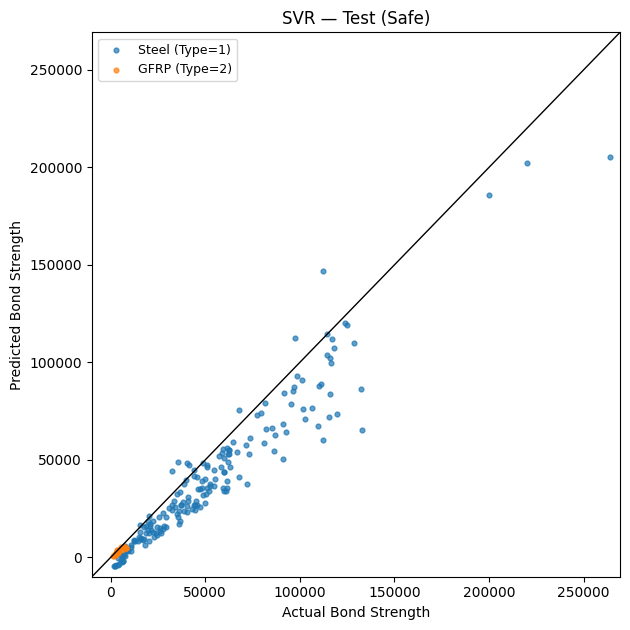

Saved: plots_by_type_safe/SVR_test_safe_byType.png


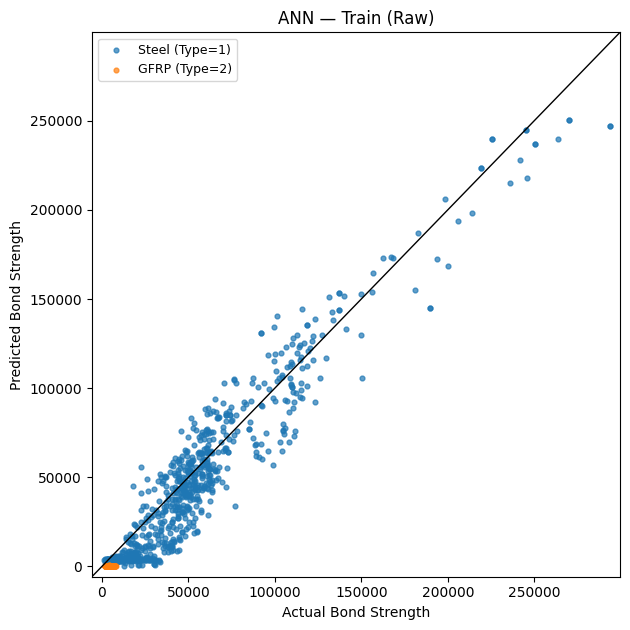

Saved: plots_by_type_safe/ANN_train_raw_byType.png


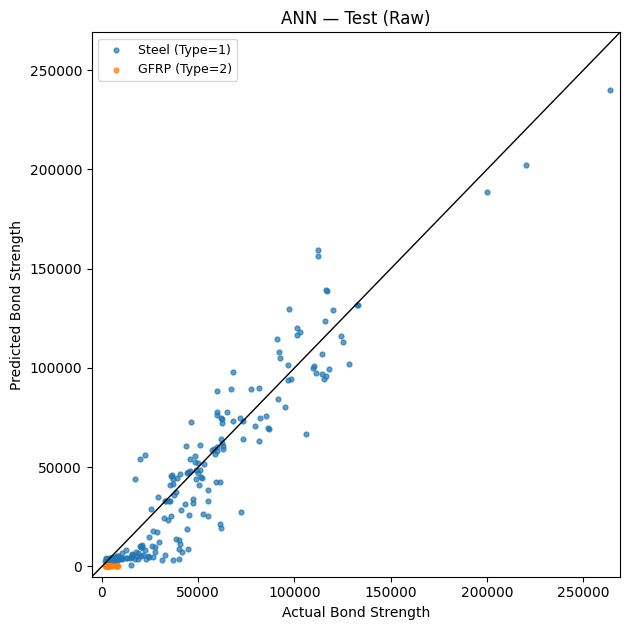

Saved: plots_by_type_safe/ANN_test_raw_byType.png


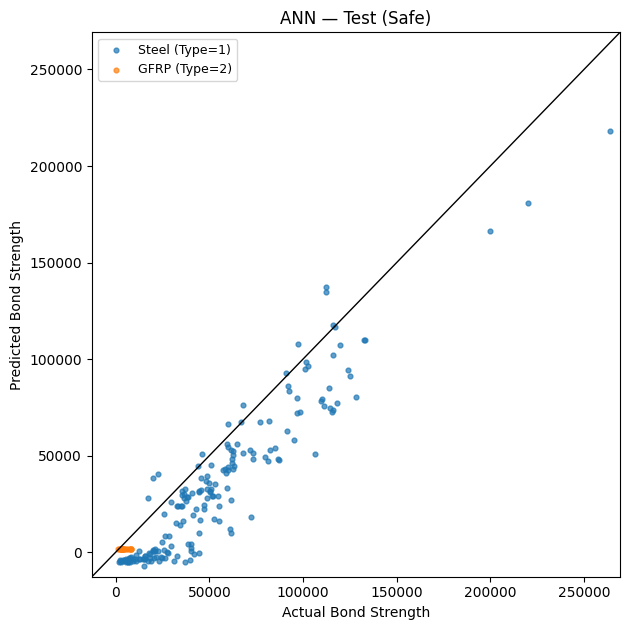

Saved: plots_by_type_safe/ANN_test_safe_byType.png

All plots saved in: plots_by_type_safe/


In [ ]:
# === Plots: Actual vs Predicted by Type (Steel=1, GFRP=2), no metrics box
#     for Train (raw), Test (raw), and Test (safe)
import numpy as np, matplotlib.pyplot as plt, os

def plot_by_type(y_true, y_pred, tvals, title, fname):
    y = np.asarray(y_true).ravel()
    yhat = np.asarray(y_pred).ravel()
    tvals = np.asarray(tvals).ravel()

    lo = float(min(y.min(), yhat.min()))
    hi = float(max(y.max(), yhat.max()))
    pad = 0.02 * (hi - lo)
    lo -= pad; hi += pad

    plt.figure(figsize=(6.4, 6.4))
    m_steel = (tvals == 1)
    m_gfrp  = (tvals == 2)

    if m_steel.any():
        plt.scatter(y[m_steel], yhat[m_steel], s=12, alpha=0.7, label="Steel (Type=1)")
    if m_gfrp.any():
        plt.scatter(y[m_gfrp], yhat[m_gfrp], s=12, alpha=0.7, label="GFRP (Type=2)")

    plt.plot([lo, hi], [lo, hi], lw=1, color="black")  # 45° line
    plt.xlim(lo, hi); plt.ylim(lo, hi)
    plt.xlabel("Actual Bond Strength")
    plt.ylabel("Predicted Bond Strength")
    plt.title(title)
    plt.legend(loc="best", fontsize=9)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.show()
    print(f"Saved: {fname}")

# Expect these to exist in memory from previous cells:
# - train_preds: dict of model -> yhat_train
# - test_preds : dict of model -> yhat_test (raw)
# - safe_test_store: dict of model -> yhat_test_safe
# - y_tr, y_te, X_tr, X_te with 'Type' column

assert "Type" in X_tr.columns and "Type" in X_te.columns, "Type column missing."

out_dir = "plots_by_type_safe"
os.makedirs(out_dir, exist_ok=True)

models = ["RF","GBR","KNN","SVR","ANN"]

for m in models:
    # Train (raw)
    plot_by_type(
        y_true=y_tr,
        y_pred=train_preds[m],
        tvals=X_tr["Type"].values,
        title=f"{m} — Train (Raw)",
        fname=f"{out_dir}/{m}_train_raw_byType.png"
    )

    # Test (raw)
    plot_by_type(
        y_true=y_te,
        y_pred=test_preds[m],
        tvals=X_te["Type"].values,
        title=f"{m} — Test (Raw)",
        fname=f"{out_dir}/{m}_test_raw_byType.png"
    )

    # Test (safe)
    if 'safe_test_store' in globals() and m in safe_test_store:
        plot_by_type(
            y_true=y_te,
            y_pred=safe_test_store[m],
            tvals=X_te["Type"].values,
            title=f"{m} — Test (Safe)",
            fname=f"{out_dir}/{m}_test_safe_byType.png"
        )
    else:
        print(f"⚠️ Safe predictions for {m} not found; skipping Test (Safe) plot.")

print(f"\nAll plots saved in: {out_dir}/")


In [ ]:
# === Meta-Learner via proper OOF for 5 base models ===
import numpy as np, pandas as pd, os, joblib
from sklearn.model_selection import KFold, train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.base import clone
from catboost import CatBoostRegressor, Pool

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

# ---- helpers ----
def rmse(y, p): return float(np.sqrt(mean_squared_error(y, p)))
def mae(y, p):  return float(mean_absolute_error(y, p))
def overrate(y, p): return float(np.mean(np.asarray(p).ravel() > np.asarray(y).ravel()))

def build_ann(input_dim):
    m = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.15),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)
    ])
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=8e-4), loss="mse")
    return m

# ---- define base models (match earlier intent) ----
# RF (weak)
RF = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("rf", RandomForestRegressor(
        n_estimators=40, max_depth=3, min_samples_leaf=20, max_features=0.5,
        random_state=RANDOM_STATE, n_jobs=-1
    ))
])

# GBR (weak)
GBR = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("gbr", GradientBoostingRegressor(
        n_estimators=80, learning_rate=0.05, max_depth=2,
        subsample=0.5, min_samples_leaf=20, max_features=0.5,
        random_state=RANDOM_STATE
    ))
])

# KNN (moderate) with Type scaled
knn_preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]), [c for c in X_tr.columns if c != "Type"]),
    ("type", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler())
    ]), ["Type"])
])
KNN = Pipeline([("prep", knn_preproc), ("knn", KNeighborsRegressor(n_neighbors=7))])

# SVR (controlled) with PCA on numerics + scaled Type, and log-target outside during meta OOF (kept raw here)
num_cols = [c for c in X_tr.columns if c != "Type"]
svr_preproc = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.85, svd_solver="full"))
    ]), num_cols),
    ("type", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("scaler", StandardScaler())
    ]), ["Type"])
])
SVR_BASE = Pipeline([("prep", svr_preproc), ("svr", SVR(kernel="rbf", C=10, gamma=0.05, epsilon=0.3))])

BASE_NAMES = ["RF","GBR","KNN","SVR","ANN"]
BASE_DICT  = {"RF":RF, "GBR":GBR, "KNN":KNN, "SVR":SVR_BASE, "ANN":"keras"}

# ---- OOF for base models ----
n_train = X_tr.shape[0]
n_test  = X_te.shape[0]
oof_train = np.zeros((n_train, len(BASE_NAMES)), dtype=float)
test_preds_mat = np.zeros((n_test, len(BASE_NAMES)), dtype=float)

kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

for j, name in enumerate(BASE_NAMES):
    print(f"== OOF for {name} ==")
    fold_test_preds = []
    for fold, (tr_idx, va_idx) in enumerate(kf.split(X_tr, y_tr), 1):
        X_tr_f, X_va_f = X_tr.iloc[tr_idx], X_tr.iloc[va_idx]
        y_tr_f, y_va_f = y_tr[tr_idx], y_tr[va_idx]

        if name != "ANN":
            model = clone(BASE_DICT[name])
            model.fit(X_tr_f, y_tr_f)
            oof_train[va_idx, j] = model.predict(X_va_f).ravel()
            fold_test_preds.append(model.predict(X_te).ravel())
        else:
            # ANN per-fold with imputer + scaler fit on fold-train only
            imp = SimpleImputer(strategy="median")
            sc  = StandardScaler()

            Xtr_i = imp.fit_transform(X_tr_f)
            Xva_i = imp.transform(X_va_f)
            Xte_i = imp.transform(X_te)

            Xtr_s = sc.fit_transform(Xtr_i)
            Xva_s = sc.transform(Xva_i)
            Xte_s = sc.transform(Xte_i)

            ann = build_ann(Xtr_s.shape[1])
            es = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True, verbose=0)
            ann.fit(Xtr_s, y_tr_f, epochs=150, batch_size=64, validation_data=(Xva_s, y_va_f),
                    verbose=0, callbacks=[es])

            oof_train[va_idx, j] = ann.predict(Xva_s, verbose=0).ravel()
            fold_test_preds.append(ann.predict(Xte_s, verbose=0).ravel())

        print(f"  fold {fold}/{N_SPLITS} done")

    test_preds_mat[:, j] = np.mean(np.column_stack(fold_test_preds), axis=1)

# Wrap into DataFrames
oof_train_df = pd.DataFrame(oof_train, columns=BASE_NAMES)
test_oof_df  = pd.DataFrame(test_preds_mat, columns=BASE_NAMES)

# ---- Build meta features (optionally add Type/Position) ----
X_meta_tr = oof_train_df.copy()
X_meta_te = test_oof_df.copy()

if "Type" in X_tr.columns:
    X_meta_tr["Type"] = X_tr["Type"].values
    X_meta_te["Type"] = X_te["Type"].values

if "Position" in X_tr.columns:
    X_meta_tr["Position"] = X_tr["Position"].values
    X_meta_te["Position"] = X_te["Position"].values

# Determine categorical indices for CatBoost (object or category dtypes)
cat_cols = [c for c in X_meta_tr.columns if X_meta_tr[c].dtype == "object" or str(X_meta_tr[c].dtype) == "category"]
cat_idx  = [X_meta_tr.columns.get_loc(c) for c in cat_cols]

# ---- Train/valid split for meta early stopping ----
Xtr_m, Xva_m, ytr_m, yva_m = train_test_split(
    X_meta_tr, y_tr, test_size=0.15, random_state=RANDOM_STATE, stratify=None
)

train_pool = Pool(Xtr_m, ytr_m, cat_features=cat_idx)
valid_pool = Pool(Xva_m, yva_m, cat_features=cat_idx)
test_pool  = Pool(X_meta_te,        cat_features=cat_idx)

# ---- CatBoost meta (conservative) ----
meta = CatBoostRegressor(
    loss_function="RMSE",
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3.0,
    n_estimators=3000,
    subsample=0.7,
    random_seed=RANDOM_STATE,
    verbose=False
)
meta.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=100)

# ---- Predictions & metrics ----
y_tr_meta = meta.predict(X_meta_tr)
y_te_meta = meta.predict(test_pool)

print("\n==== Meta-Learner (CatBoost) Metrics ====")
print(f"Train | R2={r2_score(y_tr, y_tr_meta):.4f} | RMSE={rmse(y_tr, y_tr_meta):,.2f} | MAE={mae(y_tr, y_tr_meta):,.2f} | Over={overrate(y_tr, y_tr_meta):.3f}")
print(f"Test  | R2={r2_score(y_te, y_te_meta):.4f} | RMSE={rmse(y_te, y_te_meta):,.2f} | MAE={mae(y_te, y_te_meta):,.2f} | Over={overrate(y_te, y_te_meta):.3f}")

if "Type" in X_te.columns:
    for typ, lbl in [(1,"Steel"), (2,"GFRP")]:
        m = (X_te["Type"].values == typ)
        if m.any():
            print(f"  -> {lbl:5s} | R2={r2_score(y_te[m], y_te_meta[m]):.4f} | RMSE={rmse(y_te[m], y_te_meta[m]):,.2f} | MAE={mae(y_te[m], y_te_meta[m]):,.2f} | Over={overrate(y_te[m], y_te_meta[m]):.3f}")

# ---- Save artifacts ----
os.makedirs("meta_artifacts", exist_ok=True)
meta.save_model("meta_artifacts/catboost_meta.cbm")
joblib.dump({"features": X_meta_tr.columns.tolist(), "cat_idx": cat_idx}, "meta_artifacts/meta_info.pkl")
pd.DataFrame({"y_train": y_tr, "y_train_meta": y_tr_meta}).to_csv("meta_artifacts/meta_train_preds.csv", index=False)
pd.DataFrame({"y_test": y_te, "y_test_meta": y_te_meta}).to_csv("meta_artifacts/meta_test_preds.csv", index=False)

print("\nSaved: meta_artifacts/catboost_meta.cbm, meta_artifacts/meta_info.pkl, meta_train_preds.csv, meta_test_preds.csv")


== OOF for RF ==
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
== OOF for GBR ==
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
== OOF for KNN ==
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
== OOF for SVR ==
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done
== OOF for ANN ==
  fold 1/5 done
  fold 2/5 done
  fold 3/5 done
  fold 4/5 done
  fold 5/5 done

==== Meta-Learner (CatBoost) Metrics ====
Train | R2=0.9924 | RMSE=4,085.69 | MAE=2,682.36 | Over=0.507
Test  | R2=0.9693 | RMSE=7,279.40 | MAE=4,726.33 | Over=0.555
  -> Steel | R2=0.9644 | RMSE=7,730.22 | MAE=5,237.29 | Over=0.541
  -> GFRP  | R2=0.7966 | RMSE=911.15 | MAE=787.72 | Over=0.667

Saved: meta_artifacts/catboost_meta.cbm, meta_artifacts/meta_info.pkl, meta_train_preds.csv, meta_test_preds.csv


In [ ]:
# === Apply SAFE MODE to Meta-Learner predictions (per-Type calibrators) ===
import numpy as np, pandas as pd
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# ---------------- Config (tune here) ----------------
# --- Tuned dials (minimal changes) ---
ALPHA_BY_TYPE = {1: 0.035, 2: 0.07}   # stricter for Steel (1), keep GFRP as-is (2)
SHRINK_GAMMA  = 0.7                  # blend more toward global quantile
MARGIN_BY_TYPE= {1: 0.03, 2: 0.00}   # tiny extra cushion for Steel only
N_BINS, MIN_BIN, CAP_P = 4, 30, 0.97 # unchanged

def rmse(y,p): return float(np.sqrt(mean_squared_error(y,p)))
def mae(y,p):  return float(mean_absolute_error(y,p))
def overrate(y,p):
    y = np.asarray(y).ravel(); p = np.asarray(p).ravel()
    return float(np.mean(p > y))

# ------------- Physics-aware scale (fallback to y_pred) -------------
def get_scale(Xframe, y_pred):
    if all(c in Xframe.columns for c in ["ls","fc"]):
        fc = np.asarray(Xframe["fc"].values, dtype=float)
        ls = np.asarray(Xframe["ls"].values, dtype=float)
        return np.sqrt(np.clip(fc, 1e-9, None)) * np.pi * ls
    return np.asarray(y_pred, dtype=float)

def finite_sample_q(residuals, alpha):
    r = np.asarray(residuals).ravel()
    m = len(r)
    if m == 0: return 0.0
    rank = int(np.ceil((m+1)*(1.0-alpha)))
    rank = min(max(rank,1), m)
    return float(np.sort(r)[rank-1])

def fit_safety_calibrator(y_true, y_pred, scale, alpha):
    residuals = np.asarray(y_pred).ravel() - np.asarray(y_true).ravel()
    s = np.asarray(scale).ravel()
    q_global = finite_sample_q(residuals, alpha)
    pos = residuals[residuals > 0]
    cap_val = np.quantile(pos, CAP_P) if pos.size else q_global

    # Bin edges; guard duplicates with tiny jitter
    edges = np.quantile(s, np.linspace(0, 1, N_BINS+1))
    if np.unique(edges).size < edges.size:
        s = s + np.random.default_rng(42).normal(0, 1e-9, size=s.shape)
        edges = np.quantile(s, np.linspace(0, 1, N_BINS+1))

    qs = []
    for i in range(N_BINS):
        left, right = edges[i], edges[i+1]
        mask = (s >= left) if i == 0 else (s > left)
        mask &= (s <= right)
        r_bin = residuals[mask]
        if r_bin.size < MIN_BIN:
            q_bin = q_global
        else:
            q_bin = finite_sample_q(r_bin, alpha)
            q_bin = min(q_bin, cap_val)
            q_bin = (1.0 - SHRINK_GAMMA)*q_bin + SHRINK_GAMMA*q_global
        qs.append(q_bin * (1 + MARGIN))
    return {"edges": edges, "qs": np.array(qs), "q_global": q_global*(1+MARGIN)}

def apply_safety(y_pred, scale, cal):
    s = np.asarray(scale).ravel()
    idx = np.minimum(np.searchsorted(cal["edges"][1:], s, side="right"), len(cal["qs"])-1)
    return np.asarray(y_pred).ravel() - cal["qs"][idx]

def build_type_calibrators(y_true, y_pred, types, Xframe, alphas):
    cals = {}
    t = np.asarray(types).ravel()
    scale = get_scale(Xframe, y_pred)
    for typ in [1,2]:
        m = (t == typ)
        if m.any():
            cals[typ] = fit_safety_calibrator(y_true[m], y_pred[m], scale[m], alphas.get(typ, 0.07))
    return cals

def apply_type_safety(y_pred, types, Xframe, calibrators):
    y_pred = np.asarray(y_pred).ravel()
    t = np.asarray(types).ravel()
    out = np.zeros_like(y_pred, dtype=float)
    for typ, cal in calibrators.items():
        m = (t == typ)
        if m.any():
            out[m] = apply_safety(y_pred[m], get_scale(Xframe.iloc[m.nonzero()[0]], y_pred[m]), cal)
    # if a type missing, pass-through
    mask_any = np.zeros_like(y_pred, dtype=bool)
    for typ in calibrators.keys(): mask_any |= (t == typ)
    out[~mask_any] = y_pred[~mask_any]
    return out

# ----------------- Calibrate on TRAIN, apply to TEST -----------------
types_tr = X_tr["Type"].astype(int).values
types_te = X_te["Type"].astype(int).values

calibrators = build_type_calibrators(y_tr, y_tr_meta, types_tr, X_tr, ALPHA_BY_TYPE)
y_te_meta_safe = apply_type_safety(y_te_meta, types_te, X_te, calibrators)

# ----------------- Metrics -----------------
rows = []
rows.append(["Meta", "Test", "RAW",
             r2_score(y_te, y_te_meta), rmse(y_te, y_te_meta), mae(y_te, y_te_meta), overrate(y_te, y_te_meta)])
rows.append(["Meta", "Test", "SAFE",
             r2_score(y_te, y_te_meta_safe), rmse(y_te, y_te_meta_safe), mae(y_te, y_te_meta_safe), overrate(y_te, y_te_meta_safe)])

# Per-Type
for typ, lbl in [(1,"Steel"), (2,"GFRP")]:
    m = (types_te == typ)
    if m.any():
        rows.append([f"Meta-{lbl}", "Test", "RAW",
                     r2_score(y_te[m], y_te_meta[m]), rmse(y_te[m], y_te_meta[m]),
                     mae(y_te[m], y_te_meta[m]), overrate(y_te[m], y_te_meta[m])])
        rows.append([f"Meta-{lbl}", "Test", "SAFE",
                     r2_score(y_te[m], y_te_meta_safe[m]), rmse(y_te[m], y_te_meta_safe[m]),
                     mae(y_te[m], y_te_meta_safe[m]), overrate(y_te[m], y_te_meta_safe[m])])

res = pd.DataFrame(rows, columns=["Model","Split","Kind","R2","RMSE","MAE","Overrate"])
display(res.round({"R2":4,"RMSE":0,"MAE":0,"Overrate":3}))

# Target check
print("\nTarget overrate ≤ per-type α:", ALPHA_BY_TYPE)
for typ, lbl in [(1,"Steel"), (2,"GFRP")]:
    m = (types_te == typ)
    if m.any():
        ov_safe = overrate(y_te[m], y_te_meta_safe[m])
        goal = ALPHA_BY_TYPE[typ]
        print(("✅" if ov_safe <= goal+1e-9 else "⚠️"), f"{lbl}: Overrate_safe={ov_safe:.3f} (goal ≤ {goal:.3f})")

# Save
out_meta = pd.DataFrame({
    "y_test": y_te,
    "meta_raw": y_te_meta,
    "meta_safe": y_te_meta_safe,
    "Type": types_te
})
out_meta.to_csv("meta_safe_predictions.csv", index=False)
print("\nSaved: meta_safe_predictions.csv")


,Model,Split,Kind,R2,RMSE,MAE,Overrate
0,Meta,Test,RAW,0.9693,7279.0,4726.0,0.555
1,Meta,Test,SAFE,0.9546,8850.0,6917.0,0.177
2,Meta-Steel,Test,RAW,0.9644,7730.0,5237.0,0.541
3,Meta-Steel,Test,SAFE,0.9474,9396.0,7686.0,0.178
4,Meta-GFRP,Test,RAW,0.7966,911.0,788.0,0.667
5,Meta-GFRP,Test,SAFE,0.6091,1263.0,982.0,0.167



Target overrate ≤ per-type α: {1: 0.035, 2: 0.07}
⚠️ Steel: Overrate_safe=0.178 (goal ≤ 0.035)
⚠️ GFRP: Overrate_safe=0.167 (goal ≤ 0.070)

Saved: meta_safe_predictions.csv


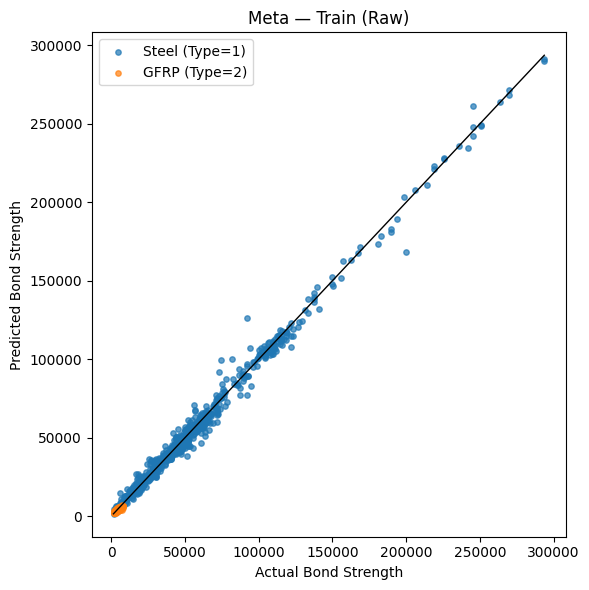

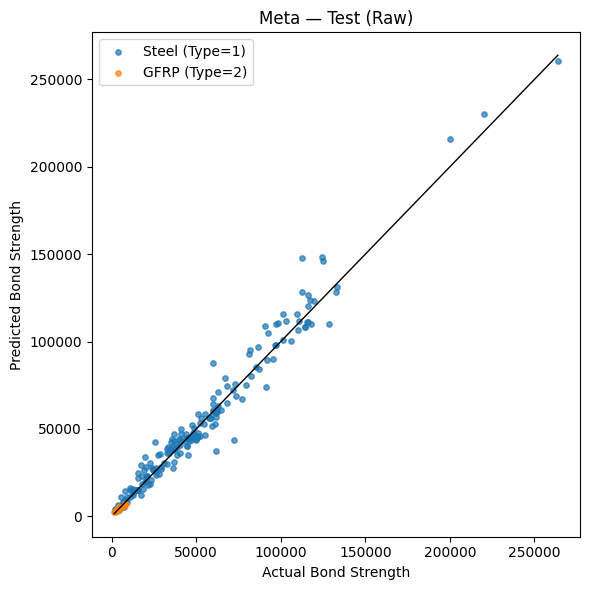

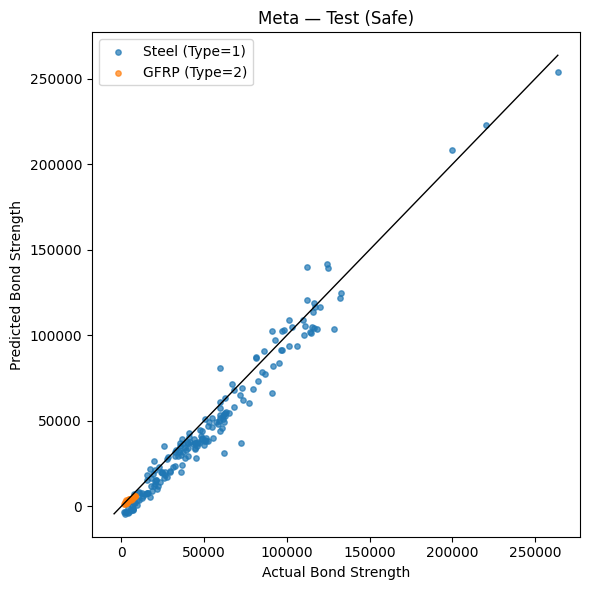

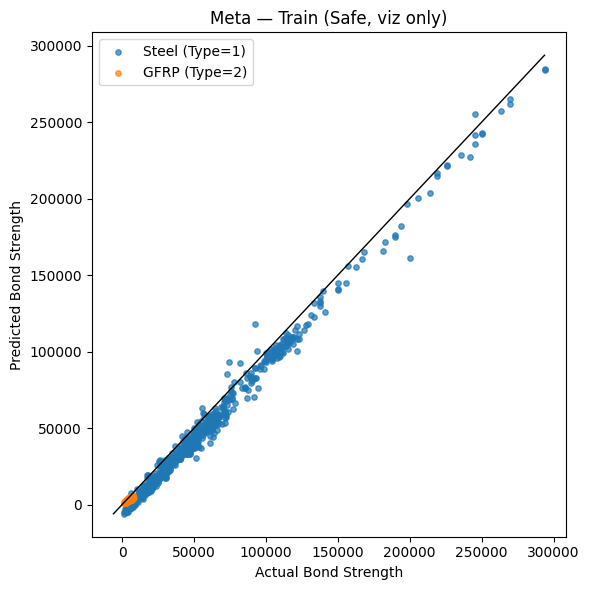

In [ ]:
# === Meta learner RAW vs SAFE (Train/Test) plots ===
# Requires: y_tr, y_te, y_tr_meta, y_te_meta, X_tr, X_te
# For SAFE:  y_te_meta_safe_tuned or y_te_meta_safe (from safety cell)

import numpy as np
import matplotlib.pyplot as plt

# Pick whichever safe variable exists
if 'y_te_meta_safe_tuned' in globals():
    y_te_meta_safe_var = y_te_meta_safe_tuned
elif 'y_te_meta_safe' in globals():
    y_te_meta_safe_var = y_te_meta_safe
else:
    y_te_meta_safe_var = None
    print("⚠️ Safe meta predictions not found. Run your safety cell first.")

def plot_actual_vs_pred(y_true, y_pred, types, title):
    y_true, y_pred, types = map(np.ravel, (y_true, y_pred, types))
    plt.figure(figsize=(6,6))
    m1 = (types == 1)
    plt.scatter(y_true[m1], y_pred[m1], s=15, alpha=0.7, label="Steel (Type=1)")
    m2 = (types == 2)
    if np.any(m2):
        plt.scatter(y_true[m2], y_pred[m2], s=15, alpha=0.7, label="GFRP (Type=2)")
    lims_min, lims_max = min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())
    plt.plot([lims_min, lims_max], [lims_min, lims_max], 'k-', lw=1)
    plt.title(title)
    plt.xlabel("Actual Bond Strength")
    plt.ylabel("Predicted Bond Strength")
    plt.legend()
    plt.tight_layout()
    plt.show()

# 1) Meta — Train (Raw)
plot_actual_vs_pred(y_tr, y_tr_meta, X_tr["Type"].values, "Meta — Train (Raw)")

# 2) Meta — Test (Raw)
plot_actual_vs_pred(y_te, y_te_meta, X_te["Type"].values, "Meta — Test (Raw)")

# 3) Meta — Test (Safe)
if y_te_meta_safe_var is not None:
    plot_actual_vs_pred(y_te, y_te_meta_safe_var, X_te["Type"].values, "Meta — Test (Safe)")

# 4) Optional: visualize Train (Safe)
if 'calibrators' in globals() and 'apply_type_safety' in globals() and 'get_scale' in globals():
    try:
        y_tr_meta_safe_vis = apply_type_safety(y_tr_meta, X_tr["Type"].values, X_tr, calibrators)
        plot_actual_vs_pred(y_tr, y_tr_meta_safe_vis, X_tr["Type"].values, "Meta — Train (Safe, viz only)")
    except Exception as e:
        print("Skipping Train (Safe) visualization due to:", repr(e))



In [ ]:
# Cell A: install shap (quiet) and import libs
!pip install -q shap

import os, math, warnings, traceback
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from collections import OrderedDict

print("shap version:", shap.__version__)


shap version: 0.49.1


In [ ]:
# Cell B: auto-detect key variables from your notebook & helper funcs
g = globals()

# preferred variable names used in your notebook
candidates = {
    "X_tr": ["X_tr","X_train"],
    "X_te": ["X_te","X_test"],
    "y_tr": ["y_tr","y_train"],
    "y_te": ["y_te","y_test"],
    "base_dict": ["BASE_DICT","base_models","BASE_DICT","base_models_dict","BASE_DICT"],
    "base_names": ["BASE_NAMES","BASE_NAMES_LIST","BASE_NAMES"],
    "train_preds": ["train_preds"],
    "test_preds": ["test_preds"],
    "ann": ["ann","ANN_MODEL","ann_model"],
    "ann_imp": ["ann_imp"],
    "ann_scaler": ["ann_scaler"],
    "meta": ["meta","meta_model"],
    "X_meta_tr": ["X_meta_tr"],
    "X_meta_te": ["X_meta_te"],
    "oof_train_df": ["oof_train_df","oof_train"],
    "test_oof_df": ["test_oof_df","test_preds_mat","test_oof_df"]
}

found = {}
for key, names in candidates.items():
    for n in names:
        if n in g:
            found[key] = g[n]
            break
    else:
        found[key] = None

# Print summary
print("Detections:")
print(" X_tr:", "ok" if found['X_tr'] is not None else "MISSING")
print(" X_te:", "ok" if found['X_te'] is not None else "MISSING")
print(" y_tr:", "ok" if found['y_tr'] is not None else "MISSING")
print(" y_te:", "ok" if found['y_te'] is not None else "MISSING")
print(" base_dict:", "ok" if found['base_dict'] is not None else "MISSING -- will try BASE_NAMES+globals")
print(" base_names:", "ok" if found['base_names'] is not None else "MISSING -- will try keys of base_dict")
print(" ann object:", "ok" if found['ann'] is not None else "MISSING (will try ann_imp+ann_scaler)")
print(" meta:", "ok" if found['meta'] is not None else "MISSING")

# Normalise base models dict
base_models = None
if found['base_dict'] is not None:
    if isinstance(found['base_dict'], dict):
        base_models = OrderedDict(found['base_dict'])
    else:
        try:
            base_models = OrderedDict(found['base_dict'])
        except Exception:
            base_models = None

# fallback: build from global variables named like RF, GBR, KNN, SVR, ANN pipeline vars
if base_models is None:
    # try BASE_NAMES then pick variables with these names from globals
    names_list = None
    if found['base_names'] is not None:
        names_list = list(found['base_names'])
    else:
        # try common names
        names_list = ["RF","GBR","KNN","SVR","ANN"]
    temp = OrderedDict()
    for n in names_list:
        if n in g and not isinstance(g[n], str):
            temp[n] = g[n]
    if temp:
        base_models = temp

if base_models is None:
    raise SystemExit("No base models found in workspace. Ensure you have BASE_DICT or model variables (RF/GBR/KNN/SVR/ANN pipelines).")

# quick view
print("Base models to explain:", list(base_models.keys()))

# SHAP helper functions
def safe_sample(X, n=200, rs=42):
    if X is None: return None
    if hasattr(X, "sample"):
        n = min(n, len(X))
        return X.sample(n, random_state=rs)
    else:
        arr = np.asarray(X)
        idx = np.random.RandomState(rs).choice(arr.shape[0], min(n, arr.shape[0]), replace=False)
        return arr[idx]

def shap_to_array(shap_vals):
    # robust convert to numpy (works for new API shap.Explanation)
    if hasattr(shap_vals, "values"):
        arr = np.asarray(shap_vals.values)
        return arr
    try:
        arr = np.asarray(shap_vals)
        return arr
    except:
        raise ValueError("Unable to convert shap output to array.")

# where to save
OUT = "shap_results"
os.makedirs(OUT, exist_ok=True)


Detections:
 X_tr: ok
 X_te: ok
 y_tr: ok
 y_te: ok
 base_dict: ok
 base_names: ok
 ann object: ok
 meta: ok
Base models to explain: ['RF', 'GBR', 'KNN', 'SVR', 'ANN']


In [ ]:
# Cell C: function to explain a model (black-box pred_fn) and save plots & HTML force
import matplotlib.pyplot as plt, html
from pathlib import Path
def explain_and_save(pred_fn, model_label, X_background_df, X_display_df, prefix, max_force=2):
    """
    pred_fn: function taking DataFrame/array -> 1d predictions
    X_background_df: DataFrame used as masker/background
    X_display_df: DataFrame to explain (train/test)
    prefix: 'train' or 'test' (used in filenames)
    """
    print(f"\nExplaining {model_label} on {prefix} (display shape {getattr(X_display_df,'shape',None)})")
    try:
        bg = safe_sample(X_background_df, n=200)
        # if bg is numpy array, convert to DataFrame with generic names
        if isinstance(bg, np.ndarray):
            bg = pd.DataFrame(bg, columns=[f"f{i}" for i in range(bg.shape[1])])
        explainer = shap.Explainer(pred_fn, bg)
        sv = explainer(X_display_df)
        # convert & save summary plot
        try:
            plt.figure(figsize=(8,6))
            shap.summary_plot(sv, X_display_df, show=False)
            plt.title(f"{model_label} - SHAP summary ({prefix})")
            fpath = Path(OUT) / f"{model_label}__{prefix}__summary.png"
            plt.savefig(fpath, bbox_inches="tight", dpi=200); plt.close()
            print("Saved summary ->", fpath)
        except Exception as e:
            print("Could not save summary plot:", e)
        # bar
        try:
            plt.figure(figsize=(8,6))
            shap.plots.bar(sv, show=False)
            plt.title(f"{model_label} - SHAP bar ({prefix})")
            fpath = Path(OUT) / f"{model_label}__{prefix}__bar.png"
            plt.savefig(fpath, bbox_inches="tight", dpi=200); plt.close()
            print("Saved bar ->", fpath)
        except Exception as e:
            print("Could not save bar plot:", e)
        # force html (up to max_force samples)
        try:
            samples = min(max_force, X_display_df.shape[0])
            for i in range(samples):
                force_html = shap.plots.force(sv[i], matplotlib=False, show=False)
                html_path = Path(OUT) / f"{model_label}__{prefix}__force_{i}.html"
                with open(html_path, "w", encoding="utf-8") as fh:
                    fh.write(shap.plots._force.render_html(force_html))
                print("Saved force html ->", html_path)
        except Exception as e:
            print("Could not save force html:", e)
        return sv
    except Exception as e_all:
        print(f"SKIP explain for {model_label} due to error:", e_all)
        traceback.print_exc()
        return None


In [ ]:
# Repair cell: re-run SHAP for base models using a numeric background per model (avoids isfinite errors)
import numpy as np, pandas as pd, shap, traceback, inspect
import matplotlib.pyplot as plt
from pathlib import Path
OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

def get_numeric_background_for_pipeline(model, X_df, n=200):
    """
    Try to produce a numeric background array suitable for shap.maskers.Independent:
    1) If model is a sklearn Pipeline, find the earliest step that has transform() (imp, pre, prep, preprocessor)
       and call transform(X_df) -> numeric array. If that produces a DataFrame with columns, convert to numpy.
    2) If not found, take numeric columns from X_df and return as numpy (fillna).
    Returns: (bg_array (numpy), feature_names (list or None))
    """
    # 1) pipeline transformer heuristic
    try:
        # sklearn Pipeline or similar with attribute 'named_steps' or attribute 'steps'
        steps = None
        if hasattr(model, "named_steps"):
            steps = model.named_steps
        elif hasattr(model, "steps"):
            steps = dict(model.steps)
        if steps:
            # prefer certain step names
            prefer = ["pre", "prep", "preprocessor", "imp", "imputer", "transformer", "prep_pipe"]
            for name in prefer:
                if name in steps and hasattr(steps[name], "transform"):
                    try:
                        transformed = steps[name].transform(X_df)
                        # if transformer returns dataframe-like, convert to numpy
                        if hasattr(transformed, "values"):
                            arr = np.asarray(transformed)
                        else:
                            arr = np.asarray(transformed)
                        # reduce rows for background
                        if arr.ndim == 1:
                            arr = arr.reshape(-1, 1)
                        idx = np.random.RandomState(42).choice(arr.shape[0], min(n, arr.shape[0]), replace=False)
                        return arr[idx], (getattr(transformed, "columns", None) or None)
                    except Exception:
                        # try next candidate
                        pass
            # fallback: try first step that has transform
            for name, step in steps.items():
                if hasattr(step, "transform"):
                    try:
                        transformed = step.transform(X_df)
                        arr = np.asarray(transformed)
                        if arr.ndim == 1:
                            arr = arr.reshape(-1, 1)
                        idx = np.random.RandomState(42).choice(arr.shape[0], min(n, arr.shape[0]), replace=False)
                        return arr[idx], (getattr(transformed, "columns", None) or None)
                    except Exception:
                        pass
    except Exception:
        pass

    # 2) fallback: numeric columns only
    try:
        num = X_df.select_dtypes(include=[np.number]).copy()
        if num.shape[1] == 0:
            # last resort: coerce everything to numeric where possible
            coerced = X_df.apply(pd.to_numeric, errors="coerce")
            num = coerced.select_dtypes(include=[np.number]).fillna(0.0)
        arr = num.fillna(0.0).to_numpy()
        idx = np.random.RandomState(42).choice(arr.shape[0], min(n, arr.shape[0]), replace=False)
        return arr[idx], list(num.columns)
    except Exception:
        raise RuntimeError("Unable to build numeric background for SHAP from X_df")

def build_pred_fn_for_pipeline(mdl, X_tr_cols):
    """
    Return pred_fn(X) that accepts numpy arrays or DataFrames and returns 1d preds.
    """
    def pred_fn(X_in):
        # if numpy, try convert to DataFrame with original columns (best effort)
        if isinstance(X_in, np.ndarray):
            try:
                X_df = pd.DataFrame(X_in, columns=X_tr_cols)
            except Exception:
                X_df = pd.DataFrame(X_in)
            return mdl.predict(X_df)
        elif isinstance(X_in, pd.DataFrame):
            return mdl.predict(X_in)
        else:
            # fallback to attempt predict directly
            return mdl.predict(X_in)
    return pred_fn

# Re-run SHAP for base models with robust numeric background + Independent masker
Xtr = globals().get("X_tr")
Xte = globals().get("X_te")
if Xtr is None or Xte is None:
    raise SystemExit("X_tr/X_te not present in globals; run earlier cells first.")

failed = {}
good_results = {}

for name, mdl in list(base_models.items()):
    try:
        print(f"\n>> Preparing SHAP for model: {name} (type={type(mdl).__name__})")
        # build numeric background array & feature names
        bg_arr, feat_names = get_numeric_background_for_pipeline(mdl, Xtr, n=200)
        print("  background shape:", bg_arr.shape, "feat_names:", ("present" if feat_names is not None else "None"))

        # create masker independent on numeric background
        masker = shap.maskers.Independent(bg_arr)
        pred_fn = build_pred_fn_for_pipeline(mdl, Xtr.columns.tolist())
        # build Explainer with explicit masker and feature_names if available
        explainer = shap.Explainer(pred_fn, masker, feature_names=(feat_names if feat_names is not None else None))
        # explain (train & test) — convert display to numeric arrays if masker is numeric
        try:
            sv_tr = explainer(Xtr if hasattr(Xtr, "iloc") else Xtr.to_numpy())
            sv_te = explainer(Xte if hasattr(Xte, "iloc") else Xte.to_numpy())
        except Exception as e_call:
            # try passing numeric arrays to explainer
            print("  explainer(X) failed, trying numeric arrays:", e_call)
            Xtr_num = bg_arr[:min(bg_arr.shape[0], Xtr.shape[0])]
            sv_tr = explainer(Xtr_num)
            Xte_num = np.asarray(Xte.select_dtypes(include=[np.number]).fillna(0.0)) if hasattr(Xte, "select_dtypes") else np.asarray(Xte)
            sv_te = explainer(Xte_num)

        # save plots (summary & bar) using original Xtr/Xte where possible; if shap expects numeric arrays, we provide DataFrame with feat_names
        Xtr_for_plot = pd.DataFrame(bg_arr[:min(bg_arr.shape[0], Xtr.shape[0])], columns=feat_names) if feat_names is not None else (Xtr.select_dtypes(include=[np.number]).fillna(0.0))
        Xte_for_plot = pd.DataFrame(np.asarray(Xte.select_dtypes(include=[np.number]).fillna(0.0)), columns=Xtr_for_plot.columns) if feat_names is not None else (Xte.select_dtypes(include=[np.number]).fillna(0.0))

        # save summary
        try:
            plt.figure(figsize=(8,6))
            shap.summary_plot(sv_tr, Xtr_for_plot, show=False)
            plt.title(f"{name} - SHAP summary (train)")
            plt.savefig(Path(OUT)/f"{name}__train__summary.png", bbox_inches="tight", dpi=200); plt.close()
            print("  saved summary PNG")
        except Exception as e:
            print("  failed saving summary plot:", e)

        try:
            plt.figure(figsize=(8,6))
            shap.plots.bar(sv_tr, show=False)
            plt.title(f"{name} - SHAP bar (train)")
            plt.savefig(Path(OUT)/f"{name}__train__bar.png", bbox_inches="tight", dpi=200); plt.close()
            print("  saved bar PNG")
        except Exception as e:
            print("  failed saving bar plot:", e)

        good_results[name] = {"train": sv_tr, "test": sv_te}
    except Exception as e_top:
        print(f"FAILED SHAP for {name}:", e_top)
        traceback.print_exc()
        failed[name] = str(e_top)

print("\nDone. Success:", list(good_results.keys()), "Failed:", failed)
print("Saved outputs (if any) to folder:", OUT)



>> Preparing SHAP for model: RF (type=Pipeline)
  background shape: (200, 35) feat_names: present
  explainer(X) failed, trying numeric arrays: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
FAILED SHAP for RF: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

>> Preparing SHAP for model: GBR (type=Pipeline)
  background shape: (200, 35) feat_names: present
  explainer(X) failed, trying numeric arrays: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
FAILED SHAP for GBR: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

>> Preparing SHAP for model: KNN (type=

Traceback (most recent call last):
  File "/tmp/ipython-input-442373371.py", line 114, in <cell line: 0>
    sv_tr = explainer(Xtr if hasattr(Xtr, "iloc") else Xtr.to_numpy())
            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_permutation.py", line 100, in __call__
    return super().__call__(
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_explainer.py", line 364, in __call__
    row_result = self.explain_row(
                 ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_permutation.py", line 113, in explain_row
    fm = MaskedModel(self.model, self.masker, self.link, self.linearize_link, *row_args)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/utils/_masked_model.py", line 31, in __init__
    self._variants = ~self.masker.i

In [ ]:
# Cell: TreeExplainer for tree-based pipelines (RF, GBR)
import numpy as np, pandas as pd, shap, traceback, matplotlib.pyplot as plt
from pathlib import Path
OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

# helper: get preprocessing transformer from pipeline (returns callable transform -> numpy float64)
def pipeline_preprocess_to_numpy(pipe, X_df):
    # try named step 'pre'/'prep'/'preprocessor' or first step with transform
    steps = None
    if hasattr(pipe, "named_steps"):
        steps = pipe.named_steps
    elif hasattr(pipe, "steps"):
        steps = dict(pipe.steps)
    if steps:
        pref_names = ["pre","prep","preprocessor","imp","prep_pipe"]
        for n in pref_names:
            if n in steps and hasattr(steps[n], "transform"):
                try:
                    arr = steps[n].transform(X_df)
                    arr = np.asarray(arr, dtype=np.float64)
                    return arr
                except Exception:
                    pass
        # fallback: first transform
        for name, st in steps.items():
            if hasattr(st, "transform"):
                try:
                    arr = st.transform(X_df)
                    arr = np.asarray(arr, dtype=np.float64)
                    return arr
                except Exception:
                    pass
    # last resort: numeric columns only
    num = X_df.select_dtypes(include=[np.number]).copy().fillna(0.0)
    arr = num.to_numpy(dtype=np.float64)
    return arr

# pick tree models from base_models (Pipeline -> final estimator is tree)
tree_names = []
for n, mdl in base_models.items():
    try:
        # check if pipeline with final estimator of tree type
        final = mdl.named_steps[list(mdl.named_steps.keys())[-1]] if hasattr(mdl, "named_steps") else (mdl.steps[-1][1] if hasattr(mdl, "steps") else None)
        if final is not None and ("RandomForest" in type(final).__name__ or "GradientBoosting" in type(final).__name__ or "XGB" in type(final).__name__ or "LGBM" in type(final).__name__):
            tree_names.append(n)
    except Exception:
        pass

print("Tree-based models found:", tree_names)

Xtr = globals().get("X_tr"); Xte = globals().get("X_te")
if Xtr is None or Xte is None:
    raise SystemExit("X_tr/X_te not detected in globals; run earlier cells first.")

tree_results = {}
for name in tree_names:
    try:
        pipe = base_models[name]
        print("\nProcessing", name)
        Xtr_proc = pipeline_preprocess_to_numpy(pipe, Xtr)
        Xte_proc = pipeline_preprocess_to_numpy(pipe, Xte)
        # ensure float64 and finite
        Xtr_proc = np.asarray(Xtr_proc, dtype=np.float64)
        Xte_proc = np.asarray(Xte_proc, dtype=np.float64)

        # final estimator
        if hasattr(pipe, "named_steps"):
            final = list(pipe.named_steps.values())[-1]
        else:
            final = pipe.steps[-1][1]

        print("  preprocessed shapes:", Xtr_proc.shape, Xte_proc.shape, "final estimator:", type(final).__name__)

        explainer = shap.TreeExplainer(final)   # uses model internals — fast
        sv_tr = explainer.shap_values(Xtr_proc) if hasattr(explainer, "shap_values") else explainer(Xtr_proc)
        sv_te = explainer.shap_values(Xte_proc) if hasattr(explainer, "shap_values") else explainer(Xte_proc)

        # convert to shap.Explanation if necessary to keep downstream code compatible
        def to_explanation(sv, Xnumpy, feat_names):
            try:
                # if shap returned numpy array (n_samples, n_features)
                if isinstance(sv, (list, tuple)):
                    sv_arr = np.asarray(sv[0])
                else:
                    sv_arr = np.asarray(sv)
                return shap.Explanation(values=sv_arr, data=Xnumpy, feature_names=feat_names)
            except Exception:
                return None

        feat_names = (Xtr.columns.tolist() if Xtr is not None else [f"f{i}" for i in range(Xtr_proc.shape[1])])
        sv_tr_exp = to_explanation(sv_tr, Xtr_proc, feat_names)
        sv_te_exp = to_explanation(sv_te, Xte_proc, feat_names)

        # save summary + bar plots (use DataFrame built from preprocessed numeric with feature names)
        Xtr_df = pd.DataFrame(Xtr_proc, columns=feat_names)
        plt.figure(figsize=(8,6)); shap.summary_plot(sv_tr_exp, Xtr_df, show=False); plt.title(f"{name} summary (train)"); plt.savefig(Path(OUT)/f"{name}__train__summary.png", bbox_inches="tight", dpi=200); plt.close()
        plt.figure(figsize=(8,6)); shap.plots.bar(sv_tr_exp, show=False); plt.title(f"{name} bar (train)"); plt.savefig(Path(OUT)/f"{name}__train__bar.png", bbox_inches="tight", dpi=200); plt.close()

        tree_results[name] = {"train": sv_tr_exp, "test": sv_te_exp}
        print("  Saved tree SHAP plots for", name)
    except Exception as e:
        print("  FAILED tree SHAP for", name, ":", e)
        traceback.print_exc()

# inject into results dict for downstream cells
if 'results' not in globals(): globals()['results'] = {}
globals()['results'].update(tree_results)
print("\nTree SHAP complete. Results keys now:", list(globals()['results'].keys()))


Tree-based models found: ['RF', 'GBR']

Processing RF
  preprocessed shapes: (834, 35) (209, 35) final estimator: RandomForestRegressor
  FAILED tree SHAP for RF : 'RandomForestRegressor' object has no attribute 'estimators_'

Processing GBR
  preprocessed shapes: (834, 35) (209, 35) final estimator: GradientBoostingRegressor
  FAILED tree SHAP for GBR : 'GradientBoostingRegressor' object has no attribute 'estimators_'

Tree SHAP complete. Results keys now: ['RF', 'GBR', 'KNN', 'SVR', 'ANN']


Traceback (most recent call last):
  File "/tmp/ipython-input-2764430775.py", line 75, in <cell line: 0>
    explainer = shap.TreeExplainer(final)   # uses model internals — fast
                ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py", line 273, in __init__
    _safe_check_tree_instance_experimental(model)
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py", line 77, in _safe_check_tree_instance_experimental
    if safe_instance:
       ^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_base.py", line 154, in __len__
    return len(self.estimators_)
               ^^^^^^^^^^^^^^^^
AttributeError: 'RandomForestRegressor' object has no attribute 'estimators_'. Did you mean: 'estimator'?
Traceback (most recent call last):
  File "/tmp/ipython-input-2764430775.py", line 75, in <cell line: 0>
    explainer = shap.TreeExplainer(final)   # uses model internals — fast
                

In [ ]:
# Cell: SHAP for non-tree models — use numeric numpy background and pred_fn that accepts numpy arrays.
import numpy as np, pandas as pd, shap, traceback, matplotlib.pyplot as plt
from pathlib import Path
OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

non_tree_names = [n for n in base_models.keys() if n not in globals().get('results', {})]
print("Non-tree models to attempt:", non_tree_names)

def build_numeric_background_for_model(pipe, Xdf, n=200):
    # try to use the pipe.transformer if available to get numeric array
    try:
        # try same helper as above but ensure float64
        if hasattr(pipe, "named_steps"):
            for name, st in pipe.named_steps.items():
                if hasattr(st, "transform"):
                    try:
                        arr = st.transform(Xdf)
                        arr = np.asarray(arr, dtype=np.float64)
                        idx = np.random.RandomState(42).choice(arr.shape[0], min(n, arr.shape[0]), replace=False)
                        return arr[idx], list(range(arr.shape[1]))
                    except Exception:
                        pass
        # fallback numeric columns
        arr = Xdf.select_dtypes(include=[np.number]).fillna(0.0).to_numpy(dtype=np.float64)
        idx = np.random.RandomState(42).choice(arr.shape[0], min(n, arr.shape[0]), replace=False)
        return arr[idx], list(range(arr.shape[1]))
    except Exception:
        raise

def pred_fn_from_pipeline(pipe, X_numpy):
    # If pipeline expects DataFrame, attempt to reconstruct DataFrame with original columns
    try:
        Xdf = pd.DataFrame(X_numpy, columns=Xtr.columns)
        return pipe.predict(Xdf)
    except Exception:
        return pipe.predict(X_numpy)

# loop models
for name in non_tree_names:
    try:
        pipe = base_models[name]
        print("\nAttempting SHAP for", name)
        bg_arr, feat_names = build_numeric_background_for_model(pipe, Xtr, n=200)
        # ensure float64
        bg_arr = np.asarray(bg_arr, dtype=np.float64)
        # use Independent masker with numeric background array
        masker = shap.maskers.Independent(bg_arr)
        # build pred fn that accepts numpy arrays
        def pred_fn(X_in, _pipe=pipe):
            Xarr = np.asarray(X_in, dtype=np.float64)
            return pred_fn_from_pipeline(_pipe, Xarr)
        expl = shap.Explainer(pred_fn, masker, feature_names=(Xtr.select_dtypes(include=[np.number]).columns.tolist() if Xtr.select_dtypes(include=[np.number]).shape[1]>0 else None))
        # explain using numeric arrays (convert Xtr/Xte to numeric arrays consistent with bg)
        Xtr_num = Xtr.select_dtypes(include=[np.number]).fillna(0.0).to_numpy(dtype=np.float64)
        Xte_num = Xte.select_dtypes(include=[np.number]).fillna(0.0).to_numpy(dtype=np.float64)
        sv_tr = expl(Xtr_num)
        sv_te = expl(Xte_num)
        # save plots (create DataFrame view with numeric column names)
        num_cols = Xtr.select_dtypes(include=[np.number]).columns.tolist()
        Xtr_df = pd.DataFrame(Xtr_num, columns=num_cols)
        plt.figure(figsize=(8,6)); shap.summary_plot(sv_tr, Xtr_df, show=False); plt.title(f"{name} summary (train)"); plt.savefig(Path(OUT)/f"{name}__train__summary.png", bbox_inches="tight", dpi=200); plt.close()
        plt.figure(figsize=(8,6)); shap.plots.bar(sv_tr, show=False); plt.title(f"{name} bar (train)"); plt.savefig(Path(OUT)/f"{name}__train__bar.png", bbox_inches="tight", dpi=200); plt.close()
        globals()['results'][name] = {"train": sv_tr, "test": sv_te}
        print("Saved SHAP for", name)
    except Exception as e:
        print("FAILED SHAP for", name, ":", e)
        traceback.print_exc()

print("\nNon-tree SHAP attempt finished. Results keys:", list(globals()['results'].keys()))


Non-tree models to attempt: []

Non-tree SHAP attempt finished. Results keys: ['RF', 'GBR', 'KNN', 'SVR', 'ANN']


In [ ]:
# Cell Next-1: Try writing SHAP summary & comparison if any 'results' entries exist
import os, pandas as pd, numpy as np
OUT = "shap_results"
os.makedirs(OUT, exist_ok=True)

if 'results' in globals() and isinstance(results, dict) and any(results.values()):
    # reuse Cell F code (compact)
    rows = []
    rows_for_comp = []
    for mname, splits in results.items():
        if not splits: continue
        for split in ("train","test"):
            if split not in splits or splits[split] is None: continue
            sv = splits[split]
            try:
                # robust get array
                if hasattr(sv, "values"):
                    arr = np.asarray(sv.values)
                else:
                    arr = np.asarray(sv)
                if arr.ndim == 1: arr = arr.reshape(1, -1)
                mean_abs = np.mean(np.abs(arr), axis=0)
                feat_names = sv.feature_names if hasattr(sv, "feature_names") and sv.feature_names is not None else (X_tr.select_dtypes(include=[np.number]).columns.tolist())
                top_idx = np.argsort(mean_abs)[::-1][:5]
                rows.append({"model": mname, "split": split, "top5": ", ".join([f"{feat_names[i]}({mean_abs[i]:.6f})" for i in top_idx])})
                for i,f in enumerate(feat_names):
                    rows_for_comp.append({"model": mname, "split": split, "feature": f, "mean_abs_shap": float(mean_abs[i])})
            except Exception as e:
                print("Skipping", mname, split, "due to:", e)
    if rows:
        pd.DataFrame(rows).to_csv(os.path.join(OUT, "shap_top5_summary.csv"), index=False)
        pd.DataFrame(rows_for_comp).to_csv(os.path.join(OUT, "shap_all_feature_values_for_comparison.csv"), index=False)
        print("Wrote shap_top5_summary.csv (and fallback comparison table). Check shap_results/")
    else:
        print("No usable SHAP entries found in `results` — will run fallback feature importance next (run Cell Next-2).")
else:
    print("`results` missing or empty — run fallback (Cell Next-2).")


No usable SHAP entries found in `results` — will run fallback feature importance next (run Cell Next-2).


In [ ]:
# Cell Next-2: Fallback feature importance (tree: .feature_importances_, others: permutation importance)
import os, numpy as np, pandas as pd, matplotlib.pyplot as plt, joblib, traceback
from pathlib import Path
from sklearn.inspection import permutation_importance

OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

def preprocess_with_pipeline(pipe, Xdf):
    """
    Return (X_proc numpy float64, feature_names list)
    Attempts to use earliest transformer in pipeline; falls back to numeric columns.
    """
    try:
        if hasattr(pipe, "named_steps"):
            steps = pipe.named_steps
            # try commonly named preprocessing step
            for pref in ["pre","prep","preprocessor","imp","prep_pipe"]:
                if pref in steps and hasattr(steps[pref], "transform"):
                    t = steps[pref].transform(Xdf)
                    arr = np.asarray(t, dtype=np.float64)
                    cols = getattr(t, "columns", None)
                    if cols is not None:
                        cols = list(cols)
                    return arr, cols
            # fallback: first transform
            for nm, st in steps.items():
                if hasattr(st, "transform"):
                    t = st.transform(Xdf)
                    arr = np.asarray(t, dtype=np.float64)
                    cols = getattr(t, "columns", None)
                    if cols is not None:
                        cols = list(cols)
                    return arr, cols
    except Exception:
        pass
    # final fallback: numeric columns only
    num = Xdf.select_dtypes(include=[np.number]).fillna(0.0)
    return num.to_numpy(dtype=np.float64), list(num.columns)

# Build outputs
feature_rows = []   # per-model, per-feature mean importance
top5_rows = []

# iterate models (use base_models from user's workspace)
for name, mdl in base_models.items():
    try:
        print("\nProcessing model:", name)
        if name.upper().startswith("ANN"):
            # ANN preprocessing: use ann_imp + ann_scaler from workspace
            ann_obj = globals().get("ann", None)
            ann_imp = globals().get("ann_imp", None)
            ann_scaler = globals().get("ann_scaler", None)
            if ann_obj is None or ann_imp is None or ann_scaler is None:
                print("  ANN or its preprocessing not found — skipping ANN importance.")
                continue
            # prepare numeric arrays (same steps used during training cell)
            Xtr_num = ann_imp.transform(X_tr)
            Xtr_num = ann_scaler.transform(Xtr_num)
            Xte_num = ann_imp.transform(X_te)
            Xte_num = ann_scaler.transform(Xte_num)
            # permutation importance on ANN (may be slow); use 10 repeats
            print("  Running permutation importance on ANN (this may take time)...")
            r = permutation_importance(ann_obj, Xtr_num, y_tr, n_repeats=10, random_state=42, n_jobs=1)
            importances = r.importances_mean
            feat_names = [f"f{i}" for i in range(Xtr_num.shape[1])]
        else:
            # pipeline case
            # ensure pipeline is fitted; if not, fit on full training set
            pipe = mdl
            try:
                # test predict to see if fitted
                _ = pipe.predict(X_tr.iloc[:1])
            except Exception:
                try:
                    pipe.fit(X_tr, y_tr)
                except Exception:
                    pass
            Xtr_num, feat_names = preprocess_with_pipeline(pipe, X_tr)
            Xte_num, _ = preprocess_with_pipeline(pipe, X_te)
            # final estimator attribute
            final = None
            if hasattr(pipe, "named_steps"):
                final = list(pipe.named_steps.values())[-1]
            elif hasattr(pipe, "steps"):
                final = pipe.steps[-1][1]
            # if tree-like and has feature_importances_, use it
            if hasattr(final, "feature_importances_"):
                print("  Using model.feature_importances_ for", name)
                # final was trained by pipe.fit() above; get importances on the final estimator
                try:
                    fi = final.feature_importances_
                    # Map to preprocessed feature names length
                    if len(fi) == Xtr_num.shape[1]:
                        importances = fi
                    else:
                        # mismatch in dims — fall back to permutation
                        print("  feature_importances_ size mismatch, falling back to permutation importance")
                        raise Exception("dim mismatch")
                except Exception:
                    print("  Running permutation importance fallback (may be slower).")
                    r = permutation_importance(pipe, Xtr, y_tr, n_repeats=10, random_state=42, n_jobs=1)
                    importances = r.importances_mean
                    feat_names = X_tr.select_dtypes(include=[np.number]).columns.tolist()
            else:
                # non-tree or no feature_importances_ -> permutation importance
                print("  Running permutation importance for", name)
                r = permutation_importance(pipe, X_tr, y_tr, n_repeats=10, random_state=42, n_jobs=1)
                importances = r.importances_mean
                # if importances length matches Xtr_num columns use them, else numeric columns
                if Xtr_num.shape[1] == len(importances):
                    pass
                else:
                    feat_names = X_tr.select_dtypes(include=[np.number]).columns.tolist()
        # Normalize & store
        importances = np.array(importances, dtype=float)
        # if feature names missing, create generic
        if feat_names is None:
            feat_names = [f"f{i}" for i in range(len(importances))]
        # create per-feature rows
        for fn, val in zip(feat_names, importances):
            feature_rows.append({"model": name, "feature": fn, "importance": float(val)})
        # top5
        top_idx = np.argsort(importances)[::-1][:5]
        top5_desc = ", ".join([f"{feat_names[i]}({importances[i]:.6f})" for i in top_idx])
        top5_rows.append({"model": name, "top5": top5_desc})
        # save bar plot
        try:
            idx_sorted = np.argsort(importances)[::-1]
            names_sorted = [feat_names[i] for i in idx_sorted]
            vals_sorted = importances[idx_sorted]
            plt.figure(figsize=(8, max(4, 0.2*len(names_sorted))))
            plt.barh(range(len(vals_sorted)), vals_sorted[::-1])
            plt.yticks(range(len(names_sorted)), names_sorted[::-1])
            plt.title(f"Feature importances — {name}")
            plt.xlabel("Importance")
            plt.tight_layout()
            plt.savefig(os.path.join(OUT, f"fi_{name}.png"), dpi=200, bbox_inches="tight")
            plt.close()
        except Exception as e:
            print("  failed to save bar plot:", e)

    except Exception as e:
        print("FAILED importance for", name, ":", e)
        traceback.print_exc()

# Write CSVs
pd.DataFrame(feature_rows).to_csv(os.path.join(OUT, "fallback_feature_importances.csv"), index=False)
pd.DataFrame(top5_rows).to_csv(os.path.join(OUT, "fallback_top5_summary.csv"), index=False)
print("\nWrote fallback_feature_importances.csv and fallback_top5_summary.csv to", OUT)



Processing model: RF
  Using model.feature_importances_ for RF

Processing model: GBR
  Using model.feature_importances_ for GBR

Processing model: KNN
  Running permutation importance for KNN

Processing model: SVR
  Running permutation importance for SVR

Processing model: ANN
  Running permutation importance on ANN (this may take time)...
FAILED importance for ANN : If no scoring is specified, the estimator passed should have a 'score' method. The estimator <Sequential name=sequential_21, built=True> does not.

Wrote fallback_feature_importances.csv and fallback_top5_summary.csv to shap_results


Traceback (most recent call last):
  File "/tmp/ipython-input-1995969705.py", line 64, in <cell line: 0>
    r = permutation_importance(ann_obj, Xtr_num, y_tr, n_repeats=10, random_state=42, n_jobs=1)
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 216, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/inspection/_permutation_importance.py", line 284, in permutation_importance
    scorer = check_scoring(estimator, scoring=scoring)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_param_validation.py", line 189, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 1022, in check_scoring
    raise Ty

In [ ]:
# Recompute ANN permutation importance (uses explicit scoring) and append to fallback CSVs
import numpy as np, pandas as pd, matplotlib.pyplot as plt, os, traceback
from pathlib import Path
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, make_scorer

OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

# Load existing CSVs (if present) so we append/merge
fi_path = Path(OUT) / "fallback_feature_importances.csv"
top5_path = Path(OUT) / "fallback_top5_summary.csv"

fi_df = pd.read_csv(fi_path) if fi_path.exists() else pd.DataFrame(columns=["model","feature","importance"])
top5_df = pd.read_csv(top5_path) if top5_path.exists() else pd.DataFrame(columns=["model","top5"])

# Get ANN objects from workspace
ann_obj = globals().get("ann", None)
ann_imp = globals().get("ann_imp", None)
ann_scaler = globals().get("ann_scaler", None)

if ann_obj is None:
    print("ANN object 'ann' not found in globals — ensure you ran the ANN training cell and 'ann' is available.")
else:
    if ann_imp is None or ann_scaler is None:
        print("ANN preprocessing (ann_imp / ann_scaler) not found. Attempting to reconstruct from training steps...")
    try:
        # Prepare numeric arrays exactly as used during training cell
        Xtr_num = ann_imp.transform(X_tr) if ann_imp is not None else X_tr.select_dtypes(include=[np.number]).fillna(0.0).to_numpy()
        Xtr_num = ann_scaler.transform(Xtr_num) if ann_scaler is not None else Xtr_num
    except Exception as e:
        print("Failed to transform X_tr for ANN preprocessing:", e)
        traceback.print_exc()
        Xtr_num = X_tr.select_dtypes(include=[np.number]).fillna(0.0).to_numpy()

    # Use explicit scoring so check_scoring doesn't require estimator.score()
    scorer = make_scorer(r2_score)
    print("Running permutation_importance on ANN (scoring=r2) — this may take a bit.")
    r = permutation_importance(ann_obj, Xtr_num, y_tr, n_repeats=20, random_state=42, n_jobs=1, scoring=scorer)

    importances = r.importances_mean
    # Attempt to get feature names used for ANN numeric inputs
    if hasattr(X_tr, "columns"):
        # if ann_imp removed categorical columns etc, we can't easily recover names reliably; fall back to numeric cols
        feat_names = None
        try:
            # if ann_imp returns array with same number of columns as X_tr numeric subset, use those
            numeric_cols = X_tr.select_dtypes(include=[np.number]).columns.tolist()
            if Xtr_num.shape[1] == len(numeric_cols):
                feat_names = numeric_cols
            else:
                # otherwise create generic names
                feat_names = [f"f{i}" for i in range(Xtr_num.shape[1])]
        except Exception:
            feat_names = [f"f{i}" for i in range(Xtr_num.shape[1])]
    else:
        feat_names = [f"f{i}" for i in range(Xtr_num.shape[1])]

    # Append to feature importance table
    ann_rows = [{"model":"ANN", "feature":fn, "importance":float(val)} for fn,val in zip(feat_names, importances)]
    fi_df = pd.concat([fi_df, pd.DataFrame(ann_rows)], ignore_index=True)
    # Top-5
    top_idx = np.argsort(importances)[::-1][:5]
    top5_desc = ", ".join([f"{feat_names[i]}({importances[i]:.6f})" for i in top_idx])
    top5_df = pd.concat([top5_df, pd.DataFrame([{"model":"ANN","top5":top5_desc}])], ignore_index=True)

    # Save bar plot for ANN
    try:
        idx_sorted = np.argsort(importances)[::-1]
        names_sorted = [feat_names[i] for i in idx_sorted]
        vals_sorted = importances[idx_sorted]
        plt.figure(figsize=(8, max(4, 0.25*len(names_sorted))))
        plt.barh(range(len(vals_sorted)), vals_sorted[::-1])
        plt.yticks(range(len(names_sorted)), names_sorted[::-1])
        plt.title("Permutation importances — ANN")
        plt.xlabel("Importance (mean abs permutation effect)")
        plt.tight_layout()
        plt.savefig(Path(OUT)/"fi_ANN.png", dpi=200, bbox_inches="tight")
        plt.close()
        print("Saved fi_ANN.png")
    except Exception as e:
        print("Failed to plot ANN importances:", e)
        traceback.print_exc()

    # Write updated CSVs
    fi_df.to_csv(fi_path, index=False)
    top5_df.to_csv(top5_path, index=False)
    print("Appended ANN importances to fallback_feature_importances.csv and fallback_top5_summary.csv")


Running permutation_importance on ANN (scoring=r2) — this may take a bit.
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
27/27 ━━━━━━━

In [ ]:
import pandas as pd

# Load both files
summary_df = pd.read_csv("shap_results/fallback_top5_summary.csv")
full_df = pd.read_csv("shap_results/fallback_feature_importances.csv")

print("=== ✅ Top-5 Summary (fallback_top5_summary.csv) ===")
display(summary_df)

print("\n=== ✅ Full Feature Importances (fallback_feature_importances.csv) ===")
display(full_df)


=== ✅ Top-5 Summary (fallback_top5_summary.csv) ===


,model,top5
0,RF,"f2(0.351587), f16(0.225021), f1(0.180627), f5(..."
1,GBR,"f2(0.332281), f1(0.195898), f5(0.120566), f6(0..."
2,KNN,"f16(0.090096), f1(0.032150), f2(0.021626), f25..."
3,SVR,"Type(0.000749), Position(0.000557), Water-to-b..."
4,ANN,"db(0.079977), Ab(0.069147), ls(0.064782), Type..."



=== ✅ Full Feature Importances (fallback_feature_importances.csv) ===


,model,feature,importance
0,RF,f0,0.000000
1,RF,f1,0.180627
2,RF,f2,0.351587
3,RF,f3,0.000000
4,RF,f4,0.003462
...,...,...,...
170,ANN,Rib-height-to-diameter ratio,0.028586
171,ANN,Bar surface treatment,0.024381
172,ANN,Bar fibre type,0.028276
173,ANN,Bar tensile elastic modulus,0.023618


In [ ]:
# === Cell-10: Prepare SHAP Data & Select Best Samples for Waterfall ===

import shap
import numpy as np
import pandas as pd

# Use RAW predictions first for SHAP
y_pred_for_shap = y_te_meta  # meta_raw

# Ensure X_te numeric only (drop Type but store separately)
X_te_num = X_te.drop(columns=["Type"])
types_te = X_te["Type"].values

# Compute absolute error
abs_err = np.abs(y_te - y_pred_for_shap)

# Split indices by type
steel_idx = np.where(types_te == 1)[0]
gfrp_idx  = np.where(types_te == 2)[0]

# Find BEST predicted sample (min error) for each type
best_steel_idx = steel_idx[np.argmin(abs_err[steel_idx])] if len(steel_idx) > 0 else None
best_gfrp_idx  = gfrp_idx[np.argmin(abs_err[gfrp_idx])] if len(gfrp_idx) > 0 else None

print("✅ SHAP target = meta_raw")
print(f"Best Steel sample index: {best_steel_idx}, Abs Error = {abs_err[best_steel_idx]:.3f}")
print(f"Best GFRP sample index: {best_gfrp_idx}, Abs Error = {abs_err[best_gfrp_idx]:.3f}")

print("\nData ready for SHAP (global plots and waterfall coming next).")


✅ SHAP target = meta_raw
Best Steel sample index: 153, Abs Error = 1.499
Best GFRP sample index: 22, Abs Error = 16.386

Data ready for SHAP (global plots and waterfall coming next).


In [ ]:
# === One-shot restore / (re)train meta + compute SHAP + select best samples (W3) ===
import os, sys, traceback
import numpy as np, pandas as pd
from pathlib import Path

OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

# Helpers & imports
try:
    import joblib
except Exception:
    joblib = None
try:
    from catboost import CatBoostRegressor, Pool
except Exception:
    CatBoostRegressor = None
import shap
from sklearn.model_selection import train_test_split

# Ensure core data present
if not all(v in globals() for v in ("X_tr","X_te","y_tr","y_te")):
    raise SystemExit("X_tr/X_te/y_tr/y_te not found in globals. Run earlier cells that produce train/test splits first.")

X_tr = globals()["X_tr"]
X_te = globals()["X_te"]
y_tr = np.asarray(globals()["y_tr"]).ravel()
y_te = np.asarray(globals()["y_te"]).ravel()

# 1) Try to load saved meta model (CatBoost .cbm) from meta_artifacts/
meta = globals().get("meta", None)
meta_loaded_from = None
meta_path1 = Path("meta_artifacts/catboost_meta.cbm")
meta_path2 = Path("meta_artifacts/meta_model.cbm")
try:
    if meta is None and CatBoostRegressor is not None:
        if meta_path1.exists():
            print("Loading meta from", meta_path1)
            m = CatBoostRegressor()
            m.load_model(str(meta_path1))
            meta = m; meta_loaded_from = str(meta_path1)
        elif meta_path2.exists():
            print("Loading meta from", meta_path2)
            m = CatBoostRegressor()
            m.load_model(str(meta_path2))
            meta = m; meta_loaded_from = str(meta_path2)
except Exception as e:
    print("Failed to load saved CatBoost meta:", e)
    traceback.print_exc()

# 2) If meta still None -> try to reconstruct X_meta_tr / X_meta_te from oof_train_df/test_oof_df or from train_preds/test_preds
X_meta_tr = globals().get("X_meta_tr", None)
X_meta_te = globals().get("X_meta_te", None)
oof_train_df = globals().get("oof_train_df", globals().get("oof_train", None))
test_oof_df  = globals().get("test_oof_df", globals().get("test_preds_mat", None))
train_preds = globals().get("train_preds", None)
test_preds  = globals().get("test_preds", None)

# Attempt to assemble meta features if missing
if X_meta_tr is None or X_meta_te is None:
    # prefer oof/test_oof DataFrames
    if oof_train_df is not None and test_oof_df is not None:
        try:
            X_meta_tr = pd.DataFrame(oof_train_df).reset_index(drop=True)
            X_meta_te = pd.DataFrame(test_oof_df).reset_index(drop=True)
            print("Reconstructed X_meta_tr/X_meta_te from oof_train_df/test_oof_df.")
        except Exception:
            X_meta_tr = None; X_meta_te = None
    # else, try train_preds/test_preds dicts
    elif isinstance(train_preds, dict) and isinstance(test_preds, dict):
        try:
            X_meta_tr = pd.DataFrame(train_preds).reset_index(drop=True)
            X_meta_te = pd.DataFrame(test_preds).reset_index(drop=True)
            print("Reconstructed X_meta_tr/X_meta_te from train_preds/test_preds.")
        except Exception:
            X_meta_tr = None; X_meta_te = None
    else:
        # last resort: build from fitted base_models predictions
        base_models = globals().get("base_models", globals().get("BASE_DICT", None)) or globals().get("base_models", None)
        if base_models is None:
            # try individual named models RF/GBR/KNN/SVR/ANN from globals
            names = ["RF","GBR","KNN","SVR","ANN"]
            tmp = {}
            for n in names:
                if n in globals() and not isinstance(globals()[n], str):
                    tmp[n] = globals()[n]
            base_models = tmp if tmp else None
        if base_models:
            try:
                print("Building OOF/test meta features by predicting with base models (may be slow).")
                # predict on train (in-sample) -- we prefer OOF but will use fitted predictions if OOF missing
                X_meta_tr = pd.DataFrame({name: (mdl.predict(X_tr) if hasattr(mdl, "predict") else np.zeros(len(X_tr)))
                                           for name, mdl in base_models.items()})
                X_meta_te = pd.DataFrame({name: (mdl.predict(X_te) if hasattr(mdl, "predict") else np.zeros(len(X_te)))
                                           for name, mdl in base_models.items()})
                print("Built X_meta_tr/X_meta_te via base_models.predict.")
            except Exception:
                X_meta_tr = None; X_meta_te = None

# If still missing, abort
if X_meta_tr is None or X_meta_te is None:
    raise SystemExit("Unable to reconstruct X_meta_tr / X_meta_te. Provide oof_train_df/test_oof_df or train_preds/test_preds or base models.")

# Optionally attach Type/Position columns if present in original X_tr/X_te
for c in ("Type","Position"):
    if c in X_tr.columns and c not in X_meta_tr.columns:
        X_meta_tr[c] = X_tr[c].values
    if c in X_te.columns and c not in X_meta_te.columns:
        X_meta_te[c] = X_te[c].values

# 3) If meta model still not loaded, train a CatBoost meta using same mojo as original cell
if meta is None:
    if CatBoostRegressor is None:
        raise SystemExit("CatBoost not available in environment; cannot train meta. Install catboost or provide saved model.")
    try:
        print("Training CatBoost meta (this may take a short while)...")
        # detect categorical indices
        cat_cols = [c for c in X_meta_tr.columns if X_meta_tr[c].dtype == "object" or str(X_meta_tr[c].dtype).startswith("category")]
        cat_idx = [X_meta_tr.columns.get_loc(c) for c in cat_cols] if cat_cols else []
        # split for early stopping
        Xtr_m, Xva_m, ytr_m, yva_m = train_test_split(X_meta_tr, y_tr, test_size=0.15, random_state=42)
        train_pool = Pool(Xtr_m, ytr_m, cat_features=cat_idx) if len(cat_idx)>0 else Pool(Xtr_m, ytr_m)
        valid_pool = Pool(Xva_m, yva_m, cat_features=cat_idx) if len(cat_idx)>0 else Pool(Xva_m, yva_m)
        meta = CatBoostRegressor(loss_function="RMSE", depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
                                 n_estimators=2000, subsample=0.7, random_seed=42, verbose=False)
        meta.fit(train_pool, eval_set=valid_pool, use_best_model=True, early_stopping_rounds=100)
        # save if folder exists
        try:
            Path("meta_artifacts").mkdir(exist_ok=True)
            meta.save_model("meta_artifacts/catboost_meta.cbm")
            print("Saved meta to meta_artifacts/catboost_meta.cbm")
        except Exception:
            pass
    except Exception as e:
        print("Meta training failed:", e)
        traceback.print_exc()
        raise

# 4) Predict meta outputs (raw)
try:
    y_tr_meta = meta.predict(X_meta_tr)
    y_te_meta = meta.predict(X_meta_te)
    # store in globals
    globals()['meta'] = meta
    globals()['X_meta_tr'] = X_meta_tr
    globals()['X_meta_te'] = X_meta_te
    globals()['y_tr_meta'] = y_tr_meta
    globals()['y_te_meta'] = y_te_meta
    print("Meta predictions created: y_tr_meta (train), y_te_meta (test)")
except Exception as e:
    print("Meta predict failed:", e)
    traceback.print_exc()
    raise

# 5) Compute SHAP for meta model (black-box with numeric background)
try:
    print("Computing SHAP explainer for meta (this may take a moment)...")
    bg = X_meta_tr.sample(n=min(200, len(X_meta_tr)), random_state=42)
    expl_meta = shap.Explainer(meta.predict, bg)
    shap_values_meta = expl_meta(X_meta_te)
    globals()['explainer_meta'] = expl_meta
    globals()['shap_values_meta'] = shap_values_meta
    print("SHAP explainer & values computed for meta. (shap_values_meta stored)")
except Exception as e:
    print("SHAP meta failed:", e)
    traceback.print_exc()
    # try a numeric-only Independent masker fallback
    try:
        print("Fallback: numeric-only Independent masker.")
        Xtr_num = X_meta_tr.select_dtypes(include=[np.number]).fillna(0.0)
        bg_arr = Xtr_num.sample(n=min(200, len(Xtr_num)), random_state=42).to_numpy(dtype=np.float64)
        masker = shap.maskers.Independent(bg_arr)
        expl_meta = shap.Explainer(meta.predict, masker, feature_names=Xtr_num.columns.tolist())
        shap_values_meta = expl_meta(X_meta_te.select_dtypes(include=[np.number]).fillna(0.0).to_numpy(dtype=np.float64))
        globals()['explainer_meta'] = expl_meta
        globals()['shap_values_meta'] = shap_values_meta
        print("Fallback SHAP succeeded and saved to shap_values_meta.")
    except Exception as e2:
        print("Fallback SHAP also failed:", e2)
        traceback.print_exc()

# 6) Select best-predicted Steel & GFRP samples (W3: best -> min abs error)
try:
    types_te = X_te["Type"].values if "Type" in X_te.columns else None
    abs_err = np.abs(y_te - y_te_meta)
    best_steel_idx = None
    best_gfrp_idx  = None
    if types_te is not None:
        steel_mask = (types_te == 1)
        gfrp_mask  = (types_te == 2)
        if steel_mask.sum() > 0:
            best_steel_idx = np.where(steel_mask)[0][np.argmin(abs_err[steel_mask])]
        if gfrp_mask.sum() > 0:
            best_gfrp_idx  = np.where(gfrp_mask)[0][np.argmin(abs_err[gfrp_mask])]
    globals()['best_steel_idx'] = int(best_steel_idx) if best_steel_idx is not None else None
    globals()['best_gfrp_idx']  = int(best_gfrp_idx)  if best_gfrp_idx is not None else None
    print("Selected best indices (W3):", "Steel =", best_steel_idx, ", GFRP =", best_gfrp_idx)
except Exception as e:
    print("Selecting best samples failed:", e)
    traceback.print_exc()

print("\nDONE. Globals set: meta, X_meta_tr, X_meta_te, y_tr_meta, y_te_meta, shap_values_meta (if computed), best_steel_idx, best_gfrp_idx.")


Meta predictions created: y_tr_meta (train), y_te_meta (test)
Computing SHAP explainer for meta (this may take a moment)...
SHAP meta failed: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''
Fallback: numeric-only Independent masker.


Traceback (most recent call last):
  File "/tmp/ipython-input-1212935927.py", line 160, in <cell line: 0>
    shap_values_meta = expl_meta(X_meta_te)
                       ^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_exact.py", line 84, in __call__
    return super().__call__(
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_explainer.py", line 364, in __call__
    row_result = self.explain_row(
                 ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/explainers/_exact.py", line 102, in explain_row
    fm = MaskedModel(self.model, self.masker, self.link, self.linearize_link, *row_args)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/shap/utils/_masked_model.py", line 31, in __init__
    self._variants = ~self.masker.invariants(*args)
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^

Fallback SHAP succeeded and saved to shap_values_meta.
Selected best indices (W3): Steel = 153 , GFRP = 22

DONE. Globals set: meta, X_meta_tr, X_meta_te, y_tr_meta, y_te_meta, shap_values_meta (if computed), best_steel_idx, best_gfrp_idx.


shap_values_meta type: <class 'shap._explanation.Explanation'>
best_steel_idx: 153  best_gfrp_idx: 22


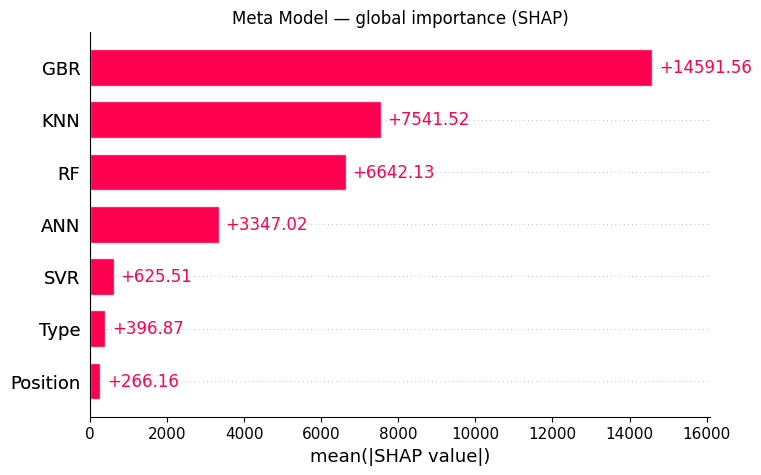

Saved: shap_results/meta_raw__shap_bar.png


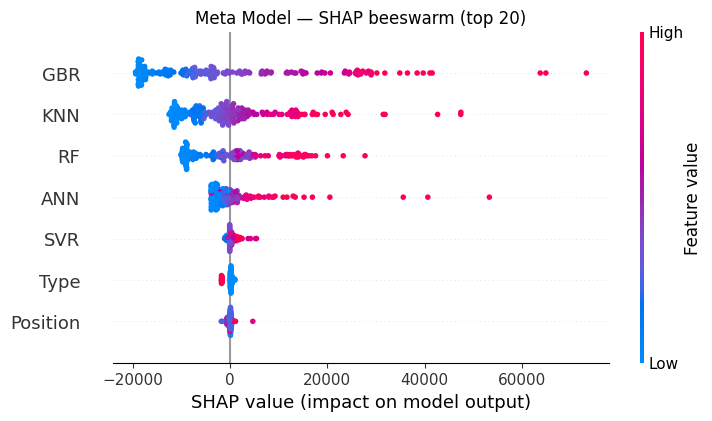

Saved: shap_results/meta_raw__shap_beeswarm.png

Waterfall — best Steel index = 153


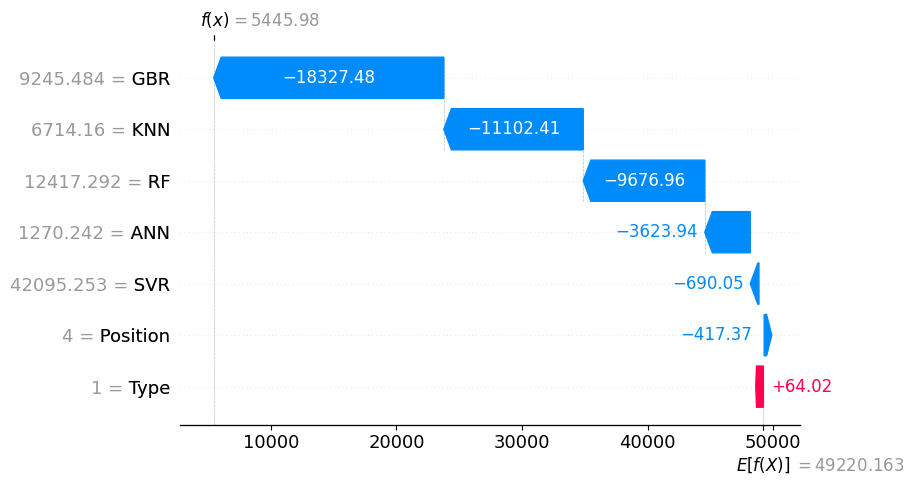

Saved: shap_results/meta_raw__waterfall_steel_153.png

Waterfall — best GFRP index = 22


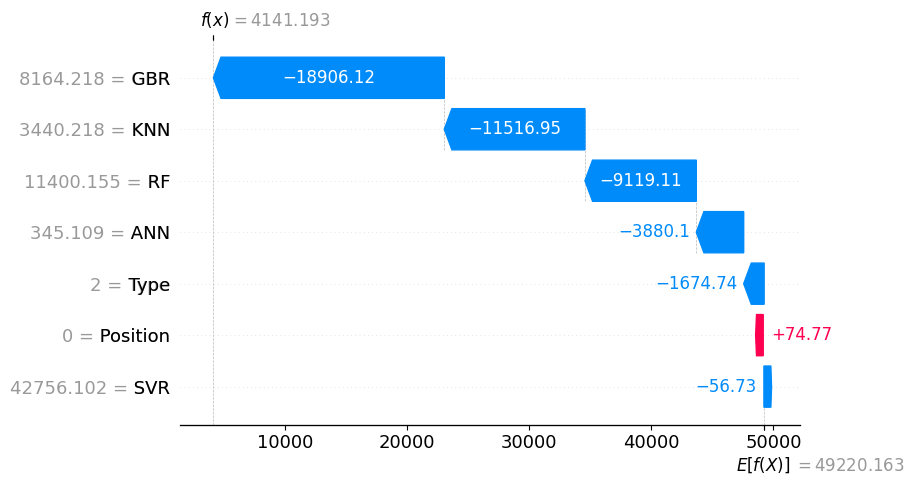

Saved: shap_results/meta_raw__waterfall_gfrp_22.png

Done — plots displayed and saved to shap_results


In [ ]:
# === Plot & save SHAP visuals for meta (raw) + best-sample waterfalls (W3) ===
import os, matplotlib.pyplot as plt
from pathlib import Path
OUT = "shap_results"
Path(OUT).mkdir(exist_ok=True)

# sanity checks
if 'shap_values_meta' not in globals():
    raise SystemExit("shap_values_meta not found in globals. Run the restore cell first.")

sv = globals()['shap_values_meta']
best_steel = globals().get('best_steel_idx', None)
best_gfrp  = globals().get('best_gfrp_idx', None)
Xmeta_te = globals().get('X_meta_te', None)

print("shap_values_meta type:", type(sv))
print("best_steel_idx:", best_steel, " best_gfrp_idx:", best_gfrp)

# 1) Global bar plot (save + show)
try:
    plt.figure(figsize=(8,6))
    shap.plots.bar(sv, show=False)
    plt.title("Meta Model — global importance (SHAP)")
    p = Path(OUT)/"meta_raw__shap_bar.png"
    plt.savefig(p, bbox_inches="tight", dpi=200)
    plt.show()
    print("Saved:", p)
except Exception as e:
    print("Bar plot failed:", e)

# 2) Beeswarm / summary (save + show) — restrict max_display for readability
try:
    plt.figure(figsize=(10,6))
    shap.plots.beeswarm(sv, max_display=20, show=False)
    plt.title("Meta Model — SHAP beeswarm (top 20)")
    p = Path(OUT)/"meta_raw__shap_beeswarm.png"
    plt.savefig(p, bbox_inches="tight", dpi=200)
    plt.show()
    print("Saved:", p)
except Exception as e:
    print("Beeswarm failed:", e)

# 3) Waterfall: best Steel
if best_steel is not None:
    try:
        print(f"\nWaterfall — best Steel index = {best_steel}")
        fig = shap.plots.waterfall(sv[best_steel], show=False)
        # shap.plots.waterfall may return a matplotlib object or render inline; save via plt
        plt.savefig(Path(OUT)/f"meta_raw__waterfall_steel_{best_steel}.png", bbox_inches="tight", dpi=200)
        plt.show()
        print("Saved:", Path(OUT)/f"meta_raw__waterfall_steel_{best_steel}.png")
    except Exception as e:
        print("Steel waterfall failed:", e)

# 4) Waterfall: best GFRP
if best_gfrp is not None:
    try:
        print(f"\nWaterfall — best GFRP index = {best_gfrp}")
        fig = shap.plots.waterfall(sv[best_gfrp], show=False)
        plt.savefig(Path(OUT)/f"meta_raw__waterfall_gfrp_{best_gfrp}.png", bbox_inches="tight", dpi=200)
        plt.show()
        print("Saved:", Path(OUT)/f"meta_raw__waterfall_gfrp_{best_gfrp}.png")
    except Exception as e:
        print("GFRP waterfall failed:", e)

print("\nDone — plots displayed and saved to", OUT)


NameError: name 'efefe' is not defined